Loading weights: 100%|██████████| 392/392 [00:00<00:00, 14875.71it/s]
/var/folders/43/ybp_t81x6gq20cd9hbjhfrtw0000gn/T/ipykernel_4433/2108335238.py:59: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(frameon=False)
Loading weights: 100%|██████████| 392/392 [00:00<00:00, 15253.15it/s]


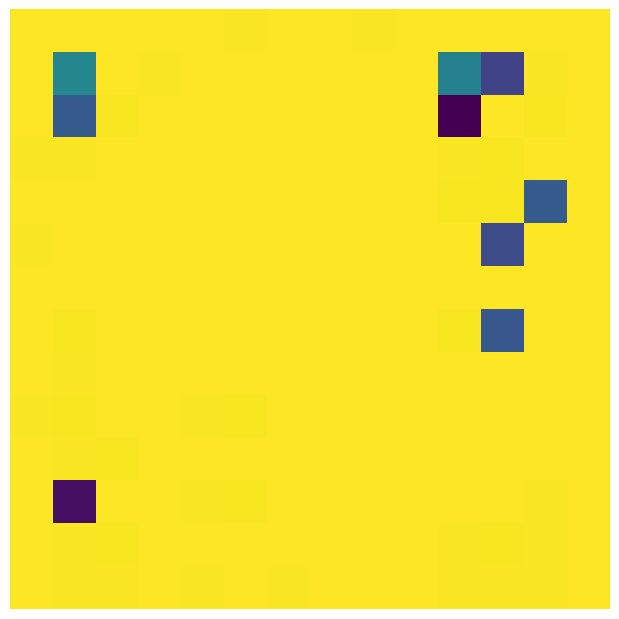

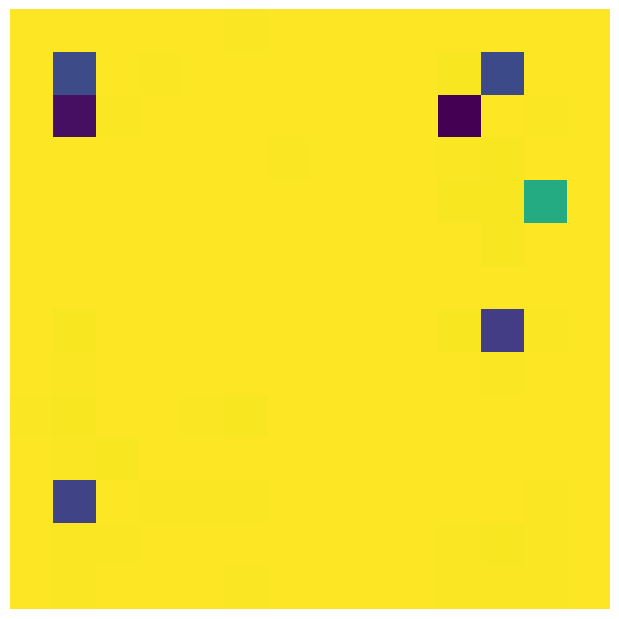

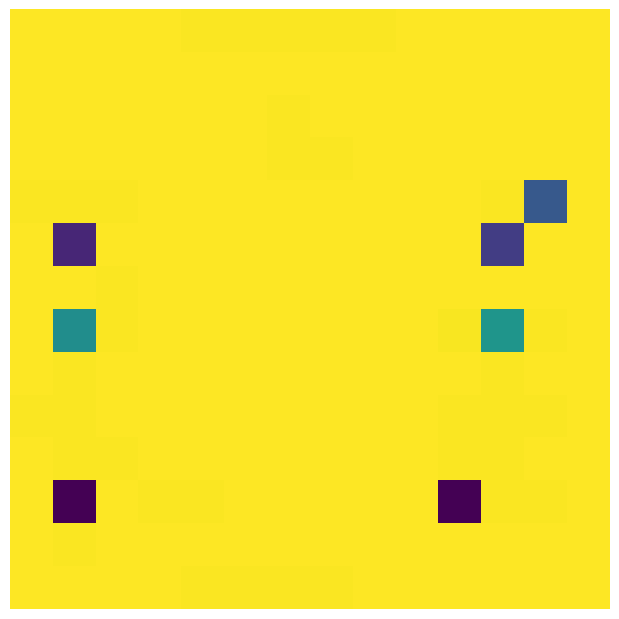

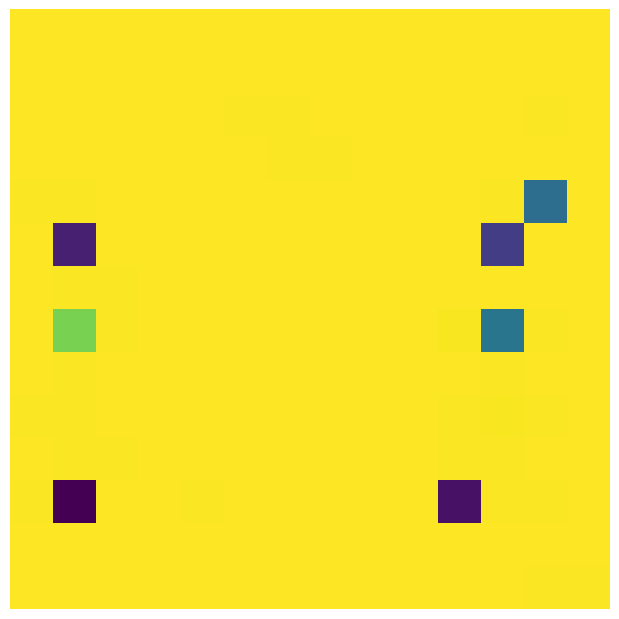

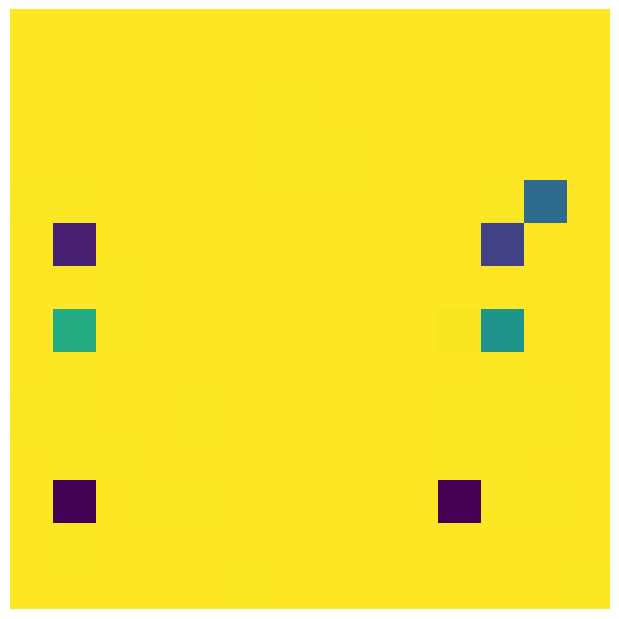

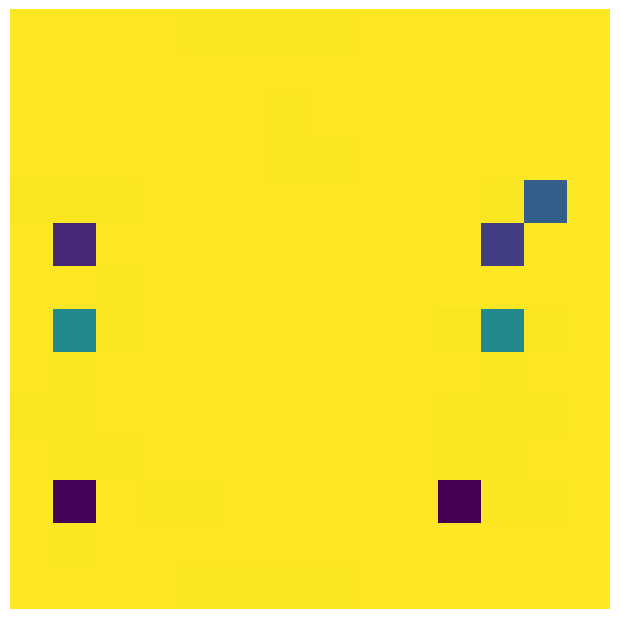

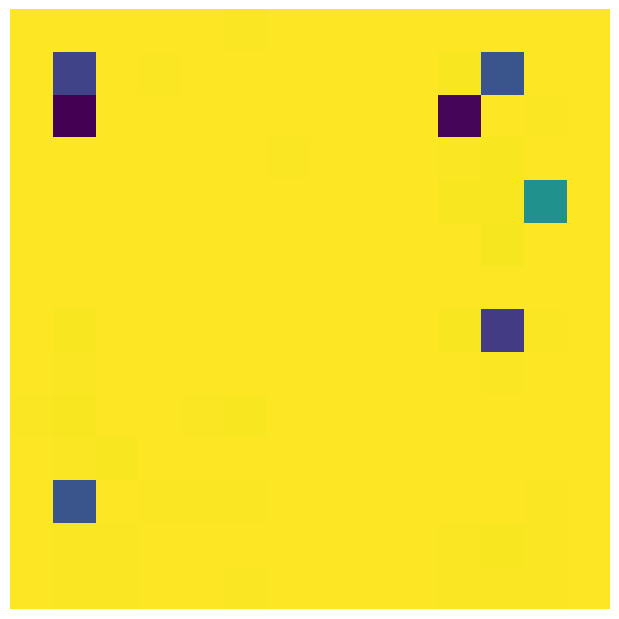

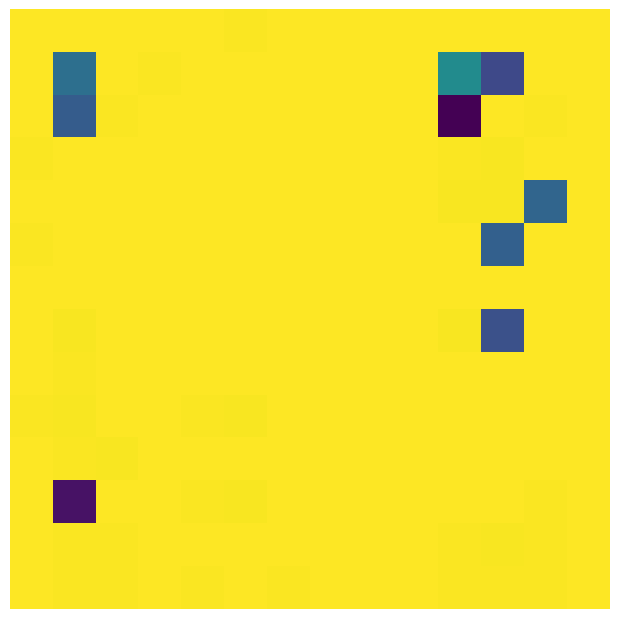

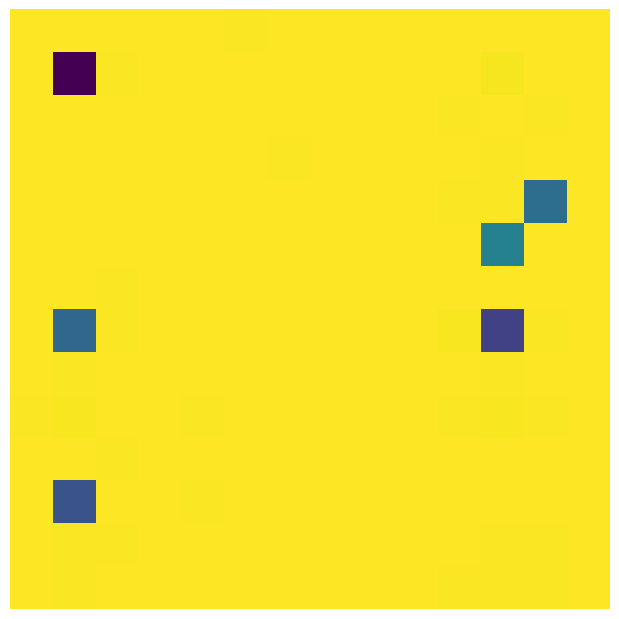

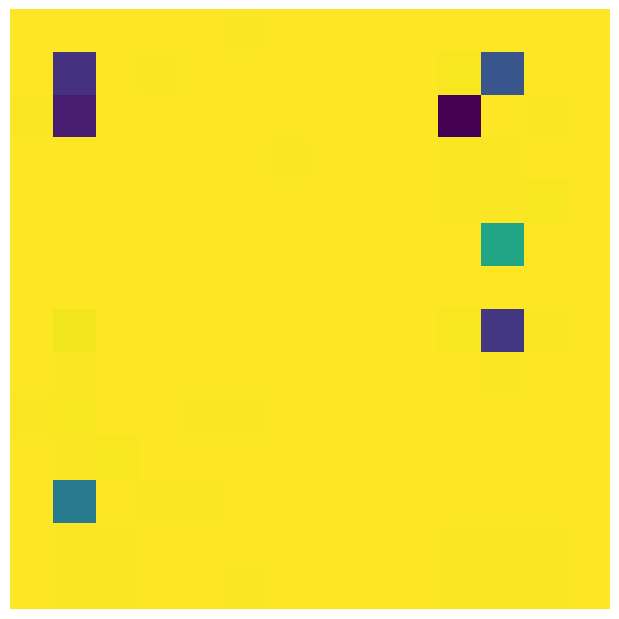

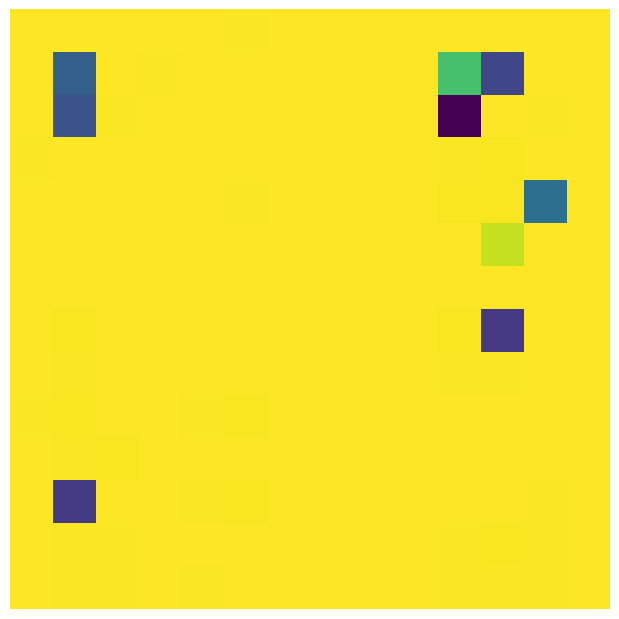

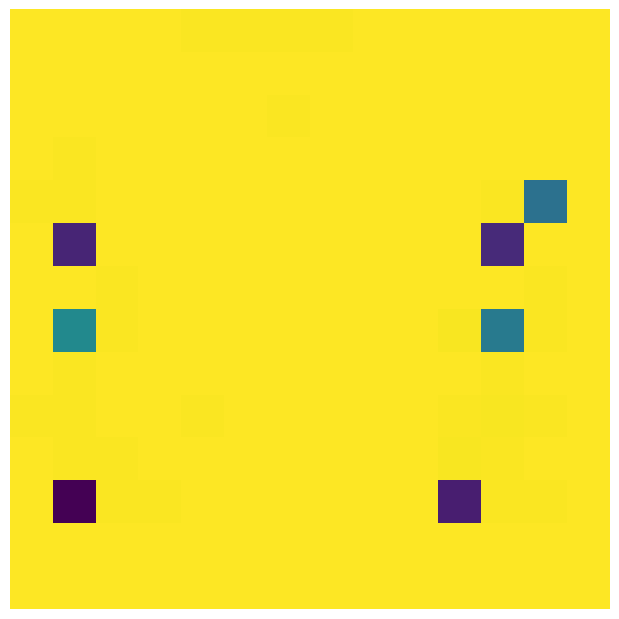

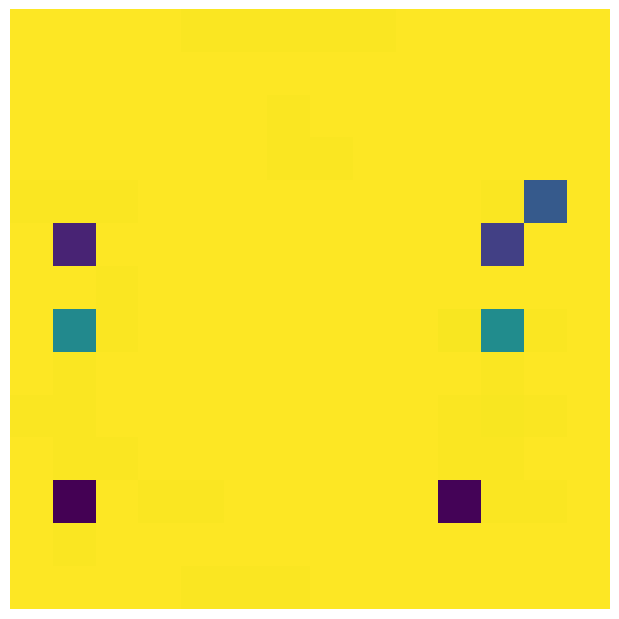

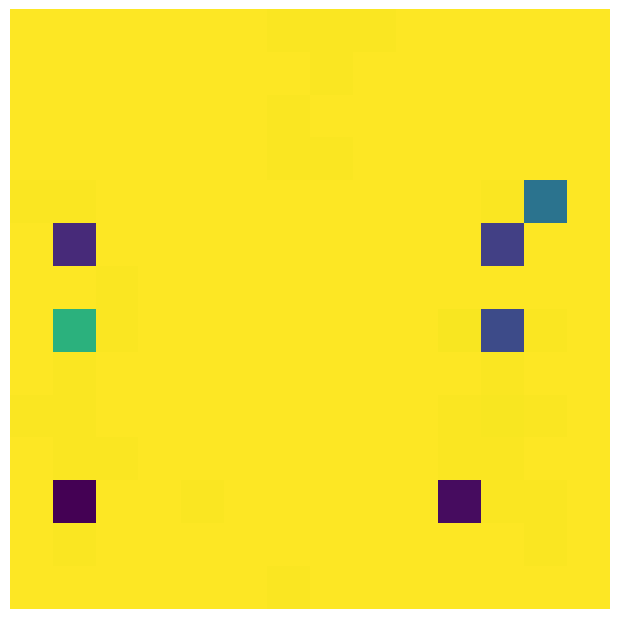

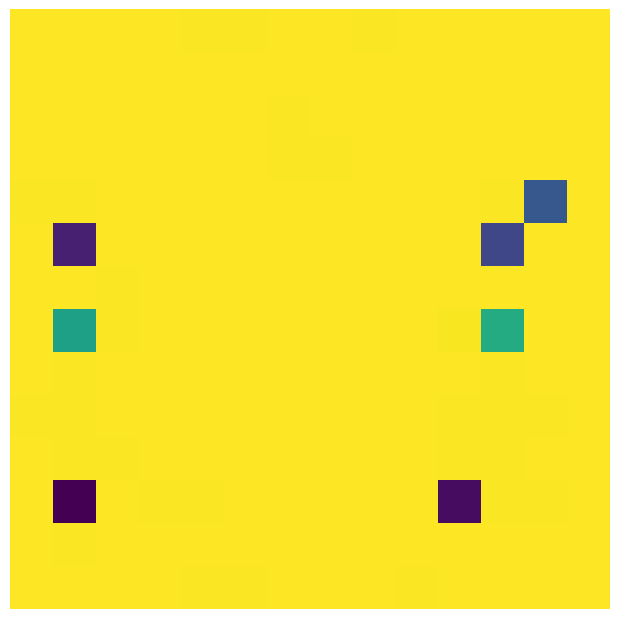

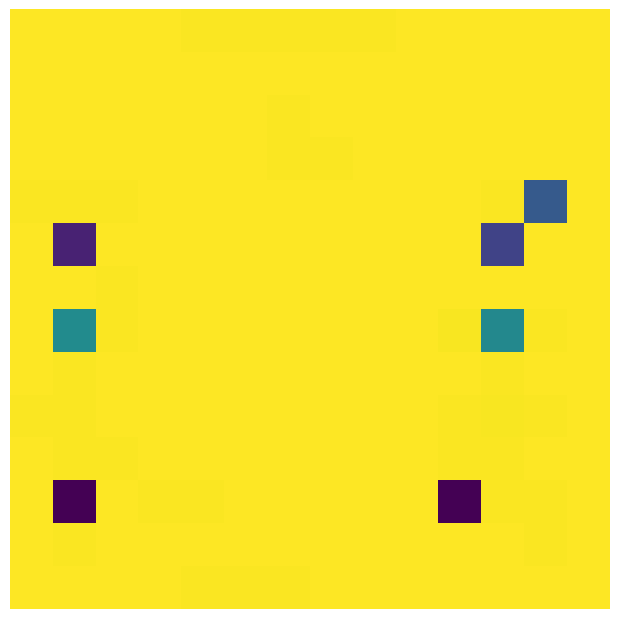

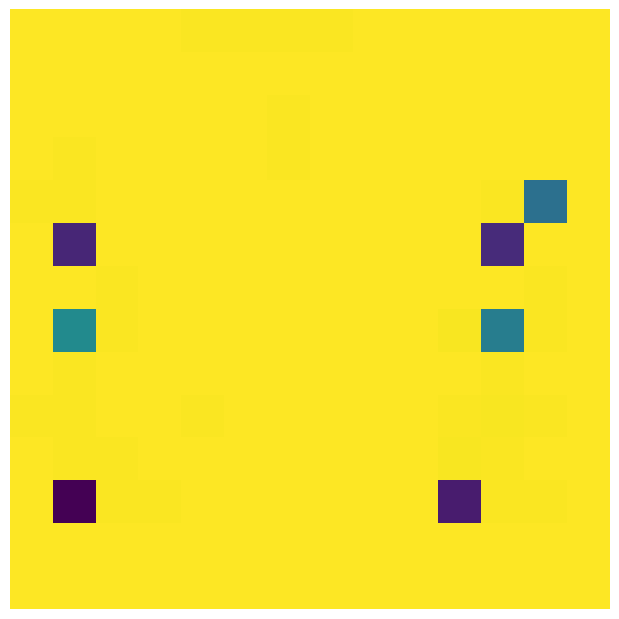

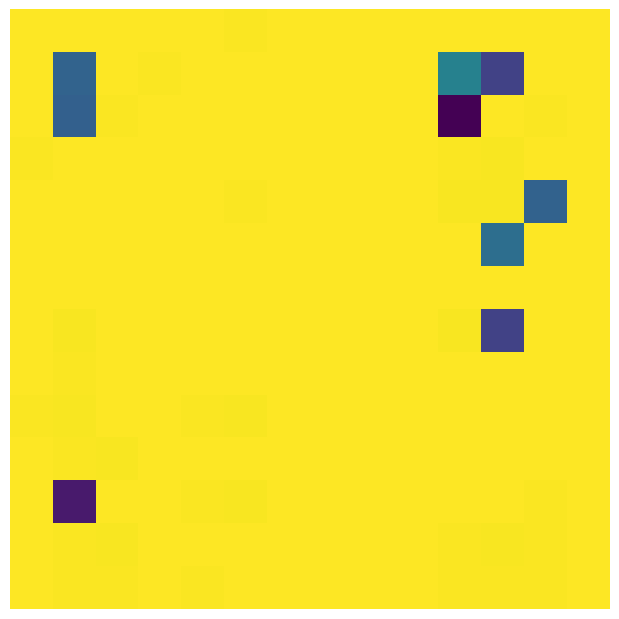

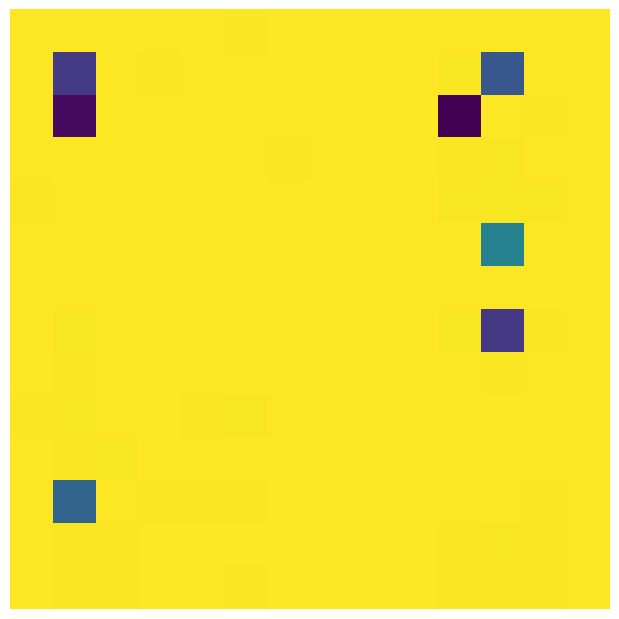

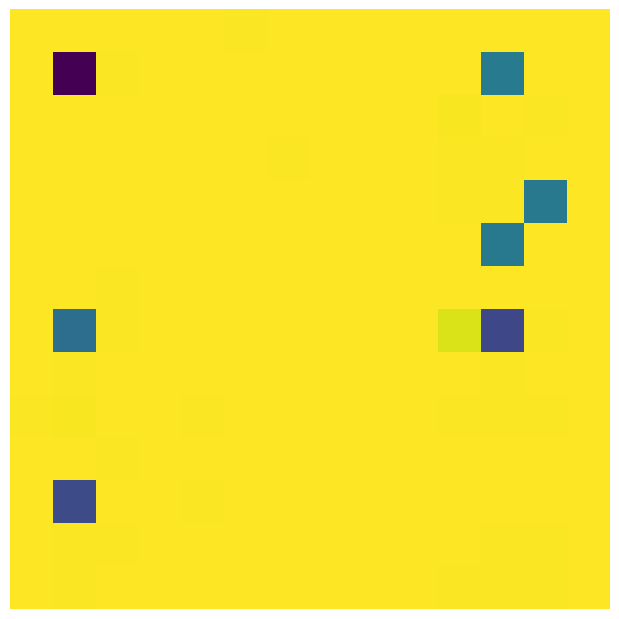

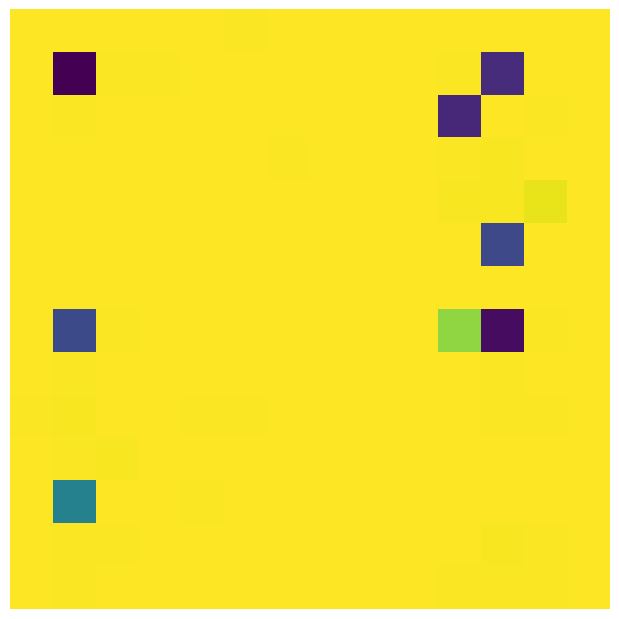

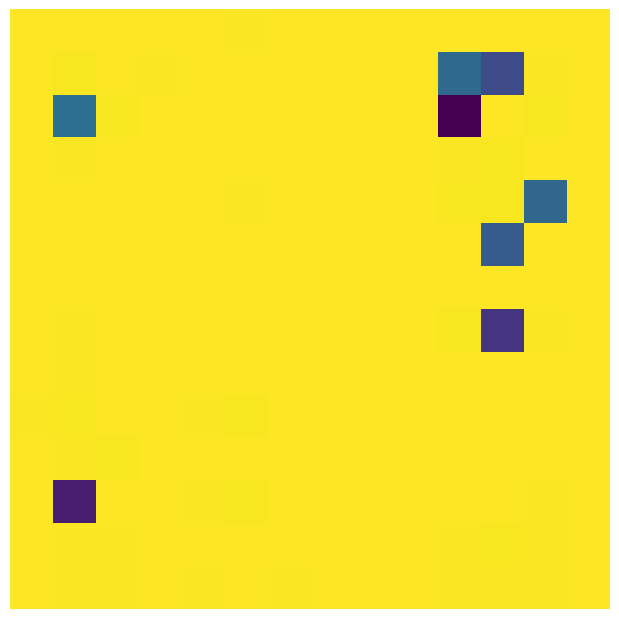

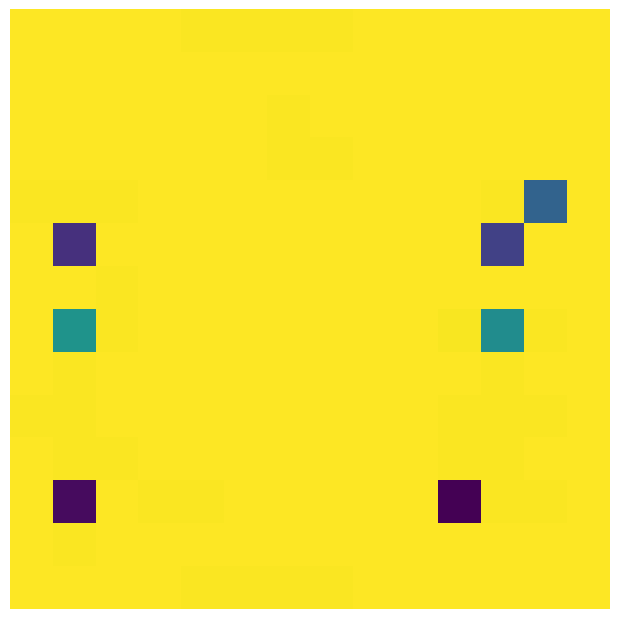

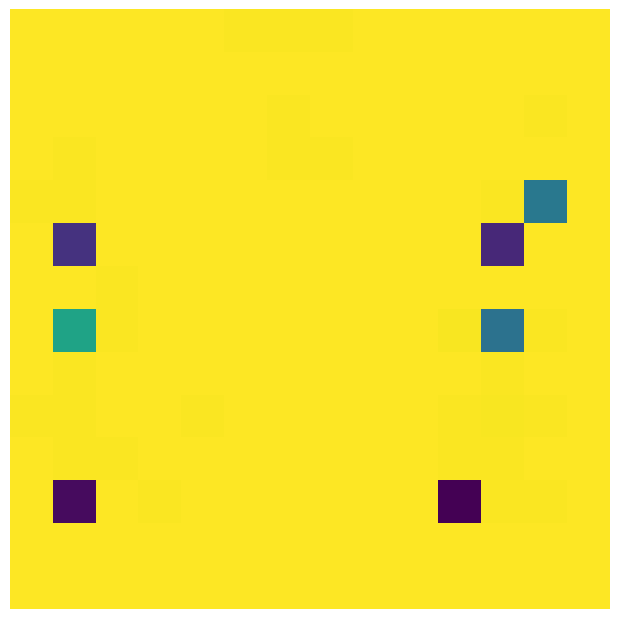

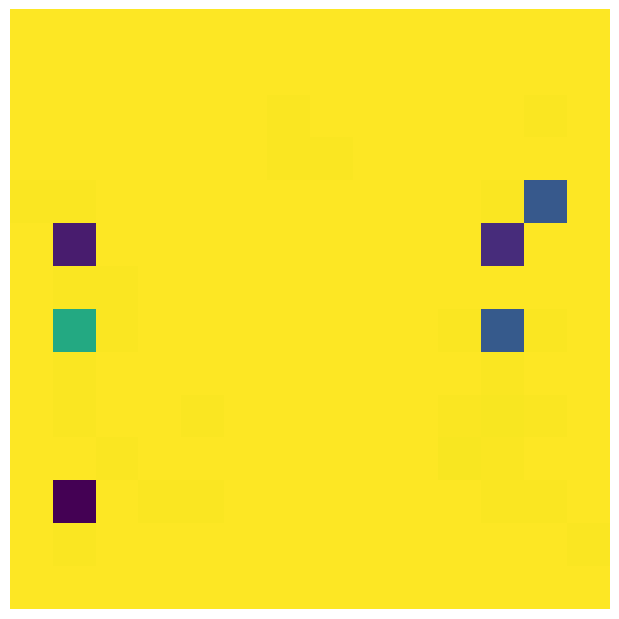

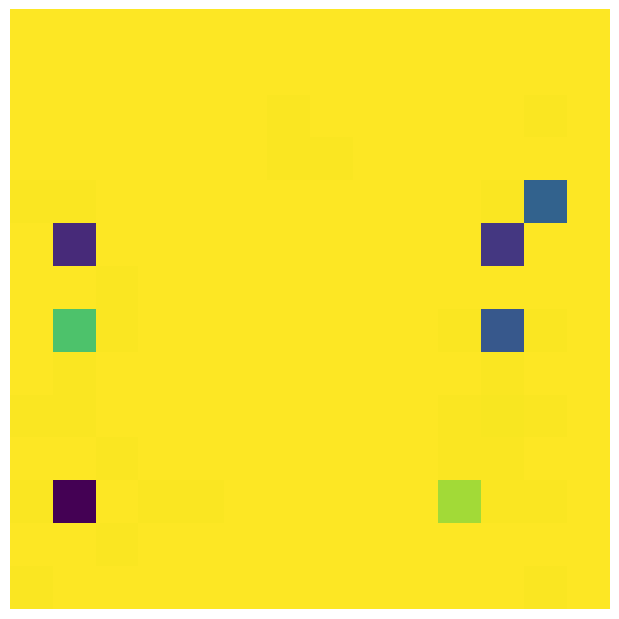

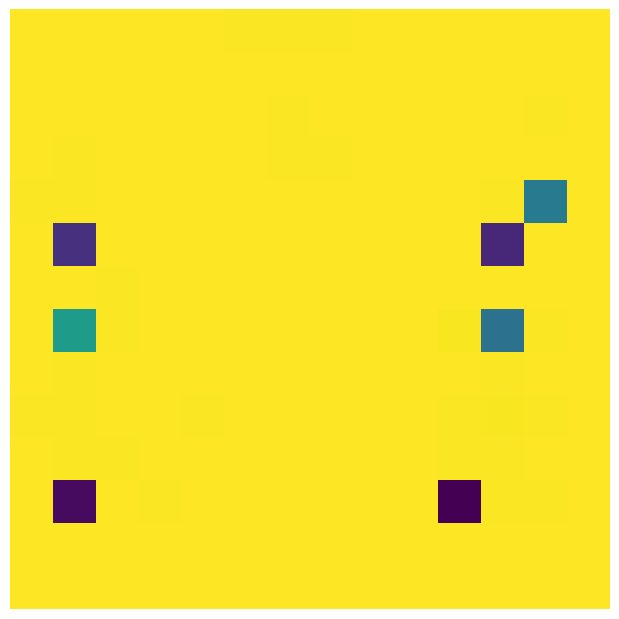

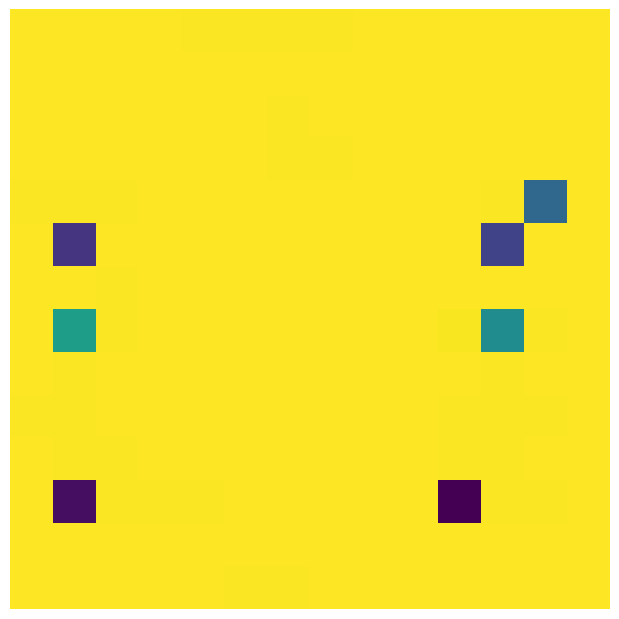

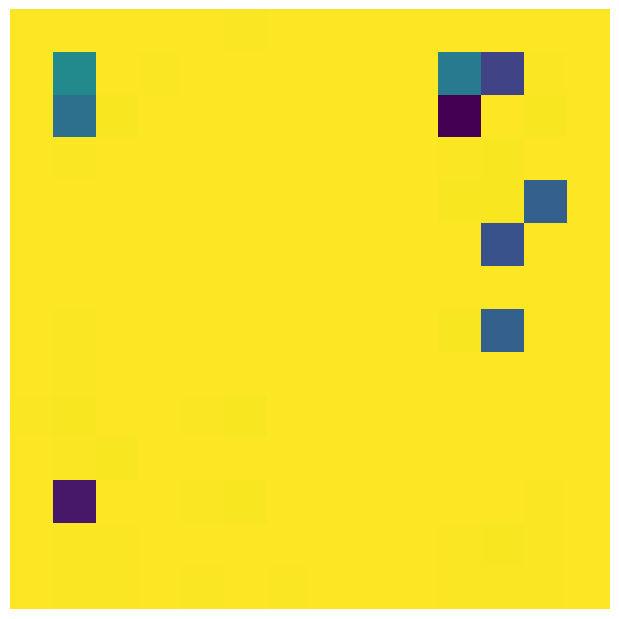

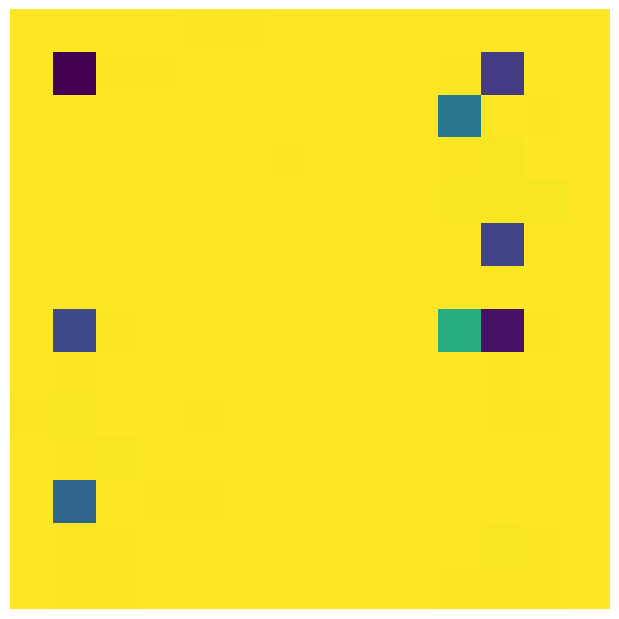

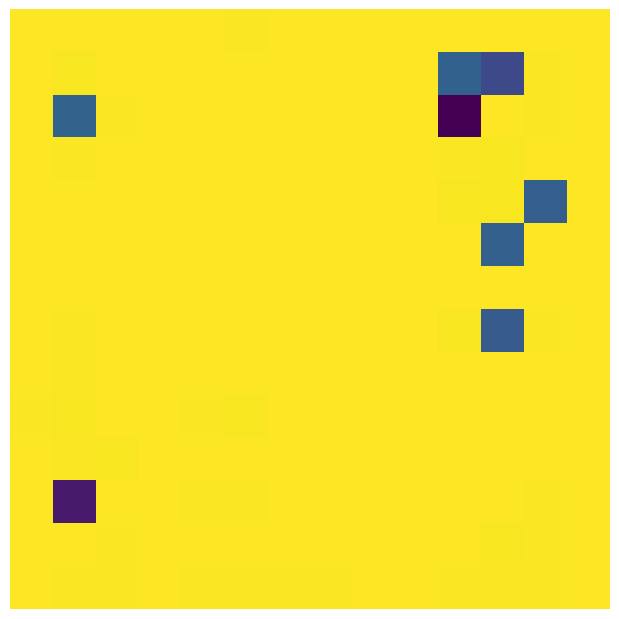

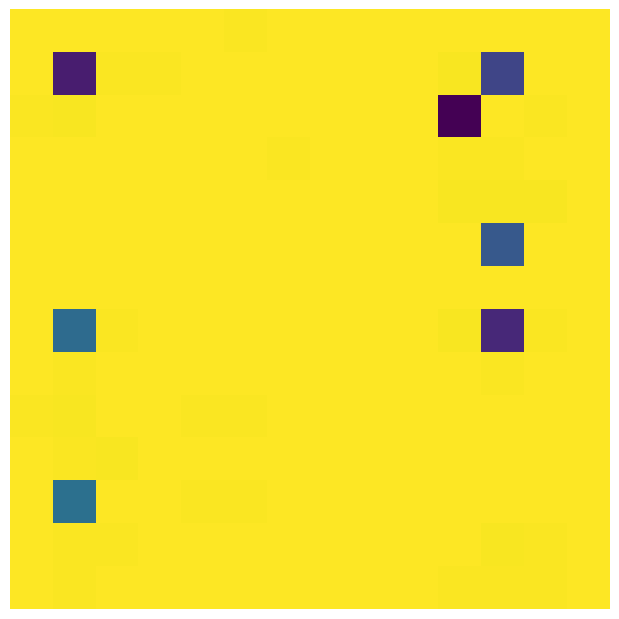

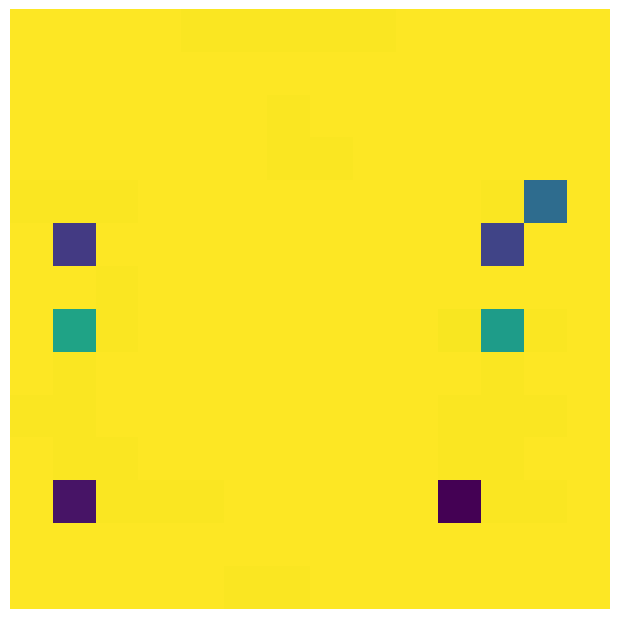

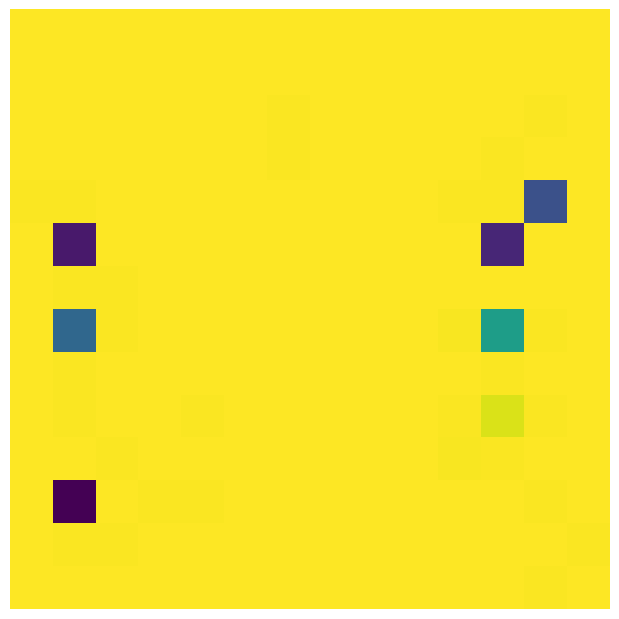

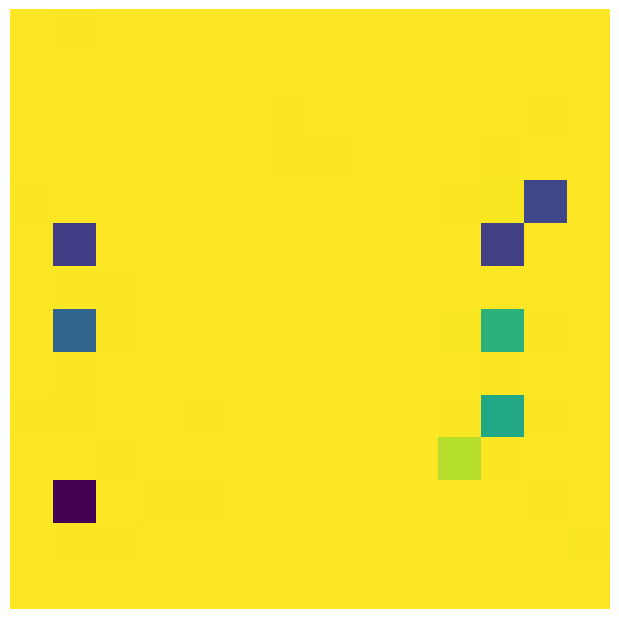

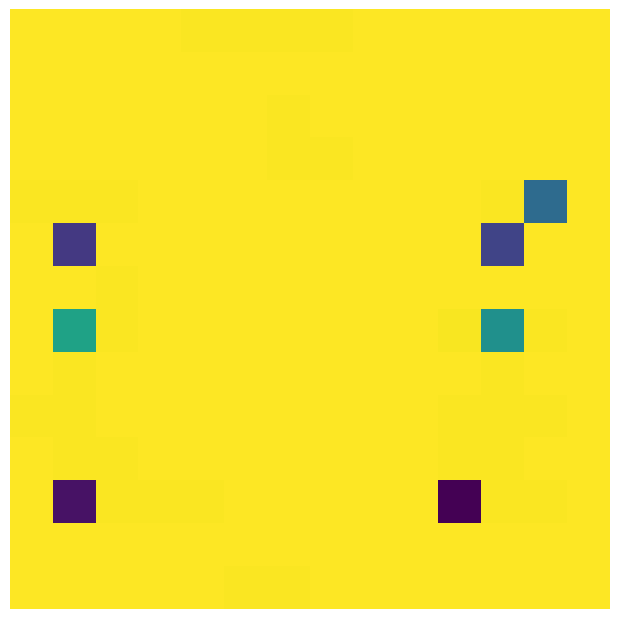

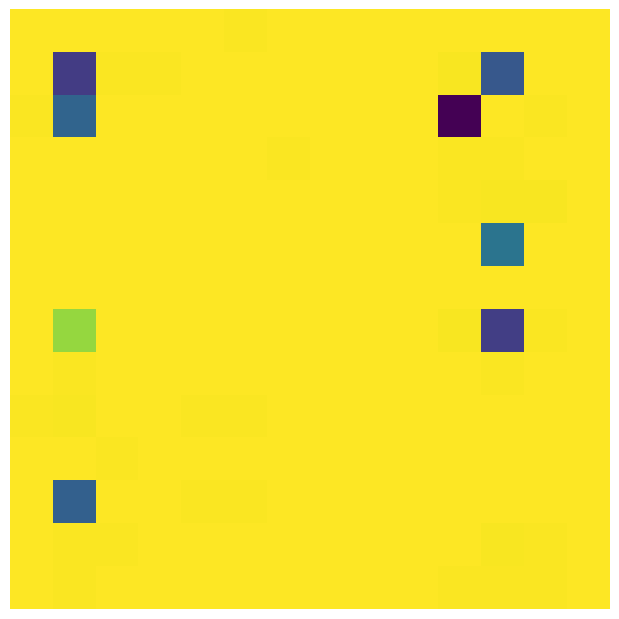

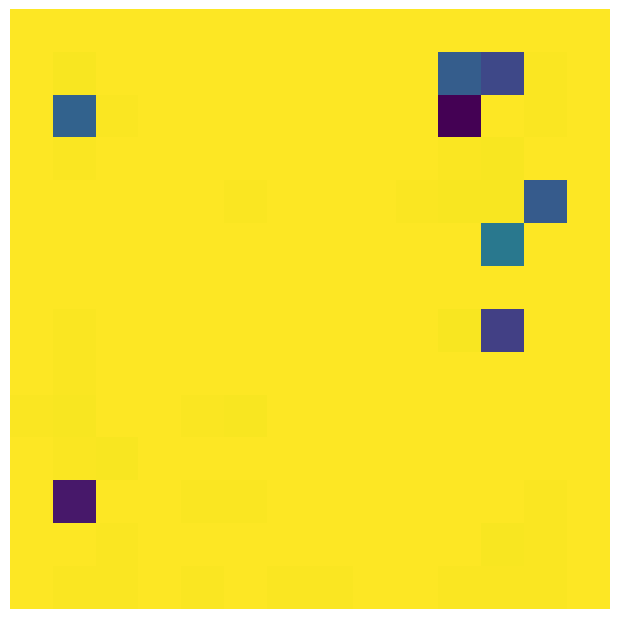

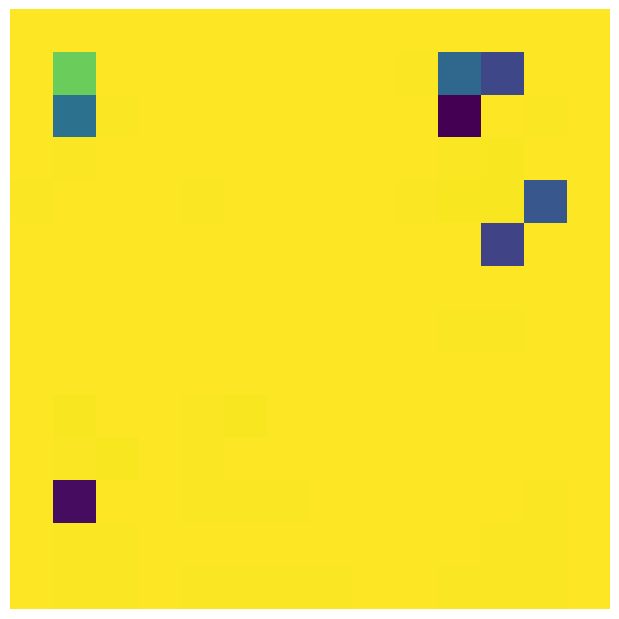

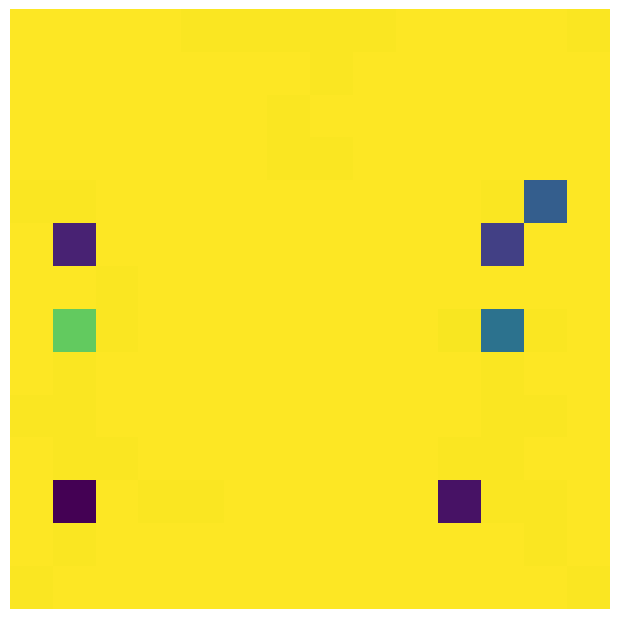

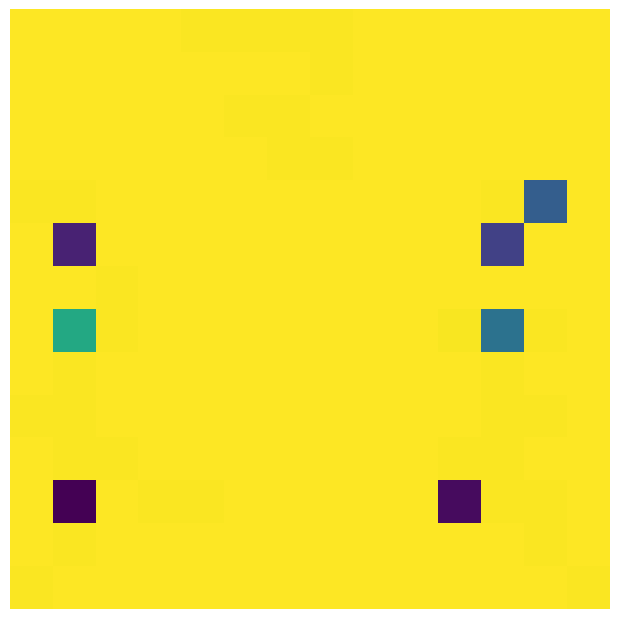

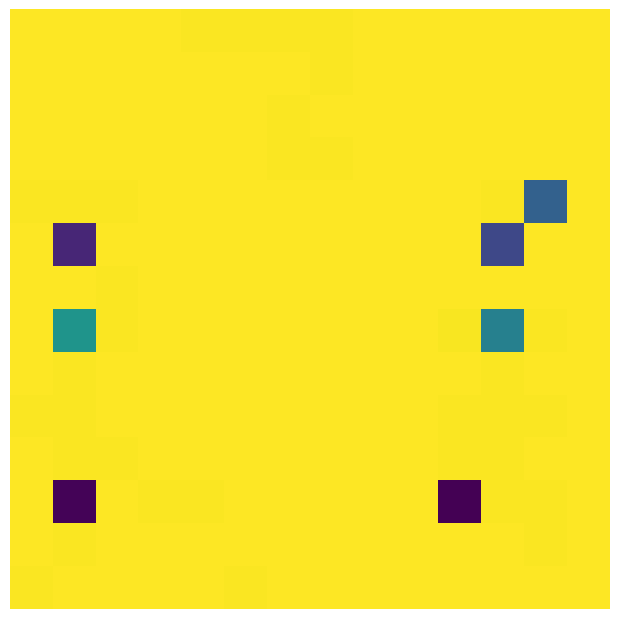

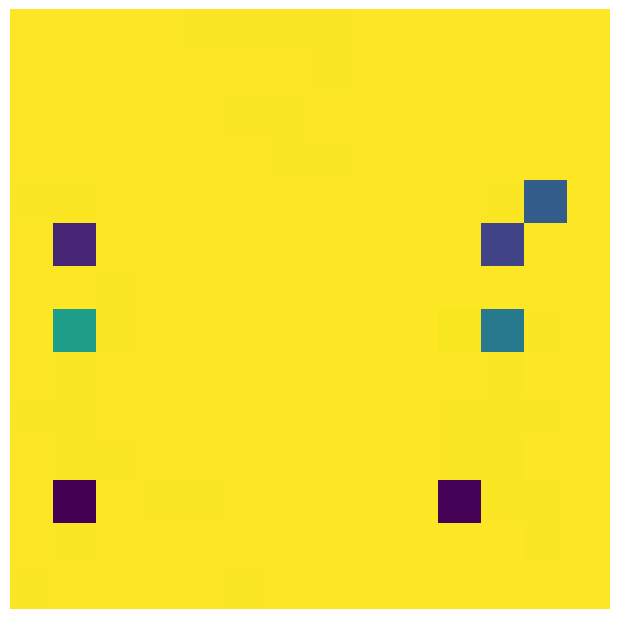

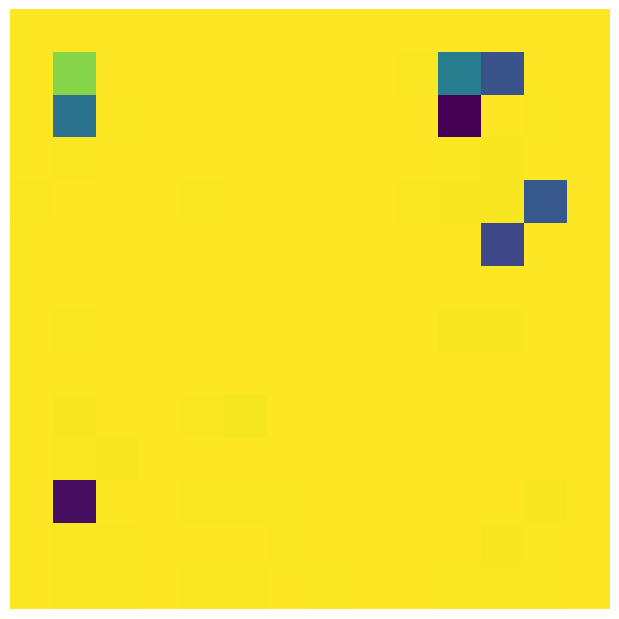

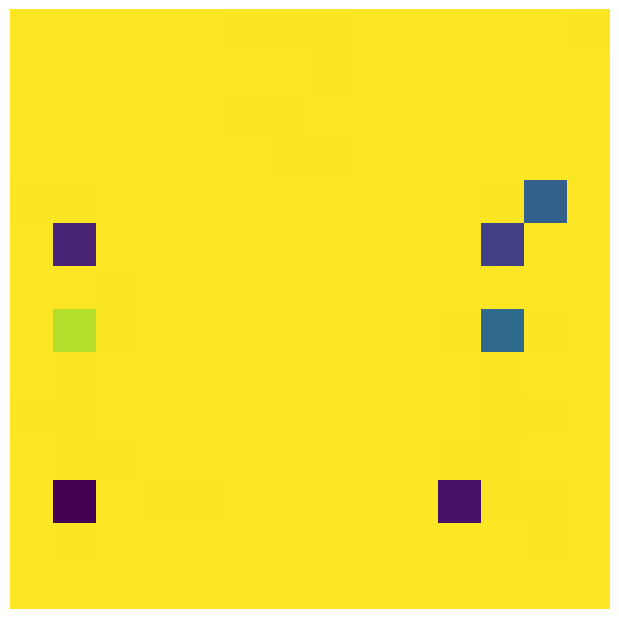

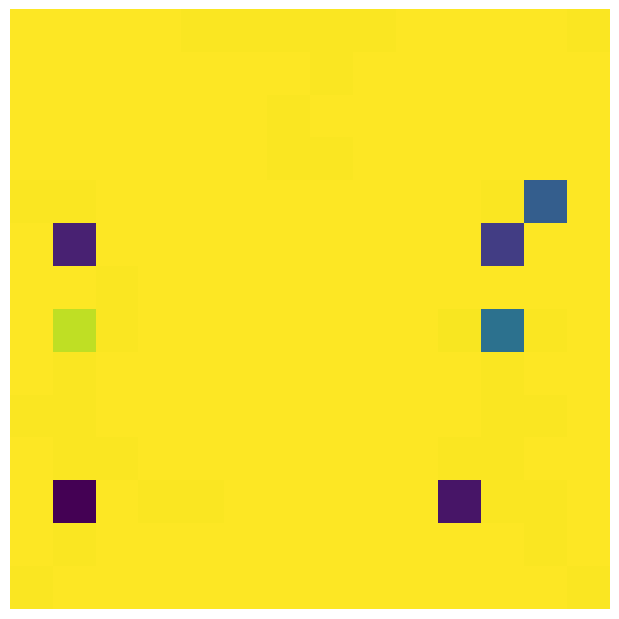

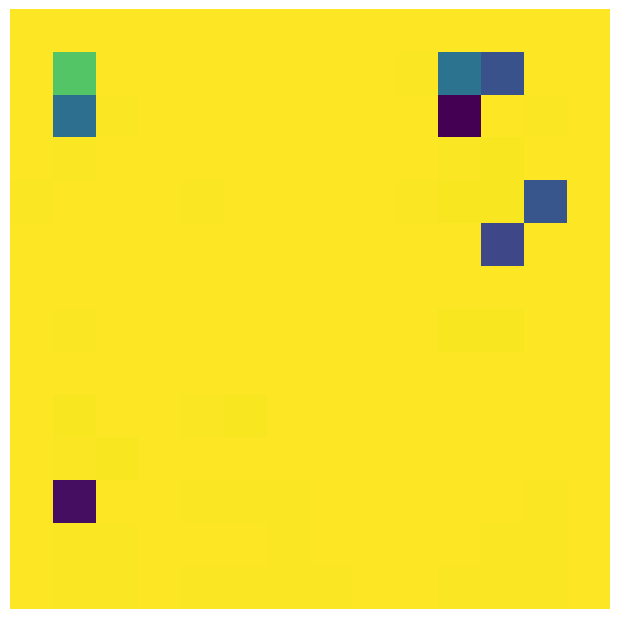

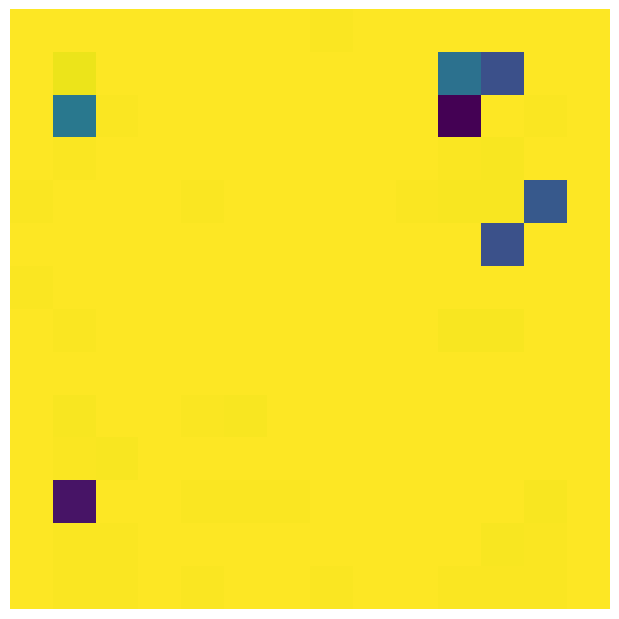

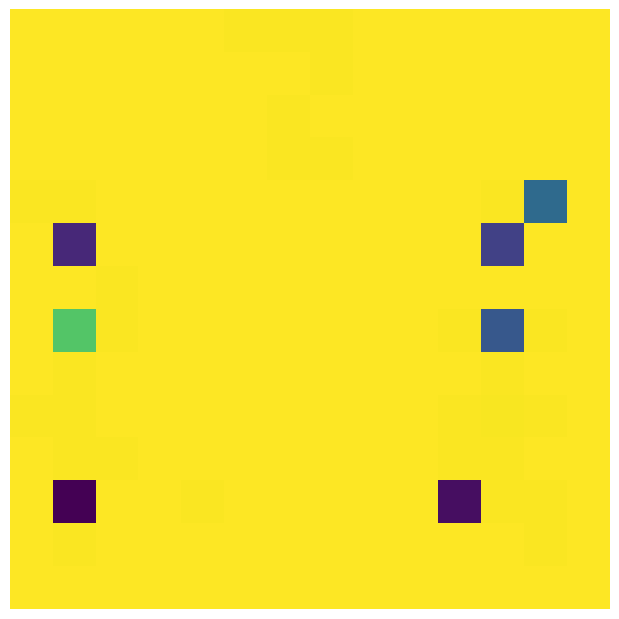

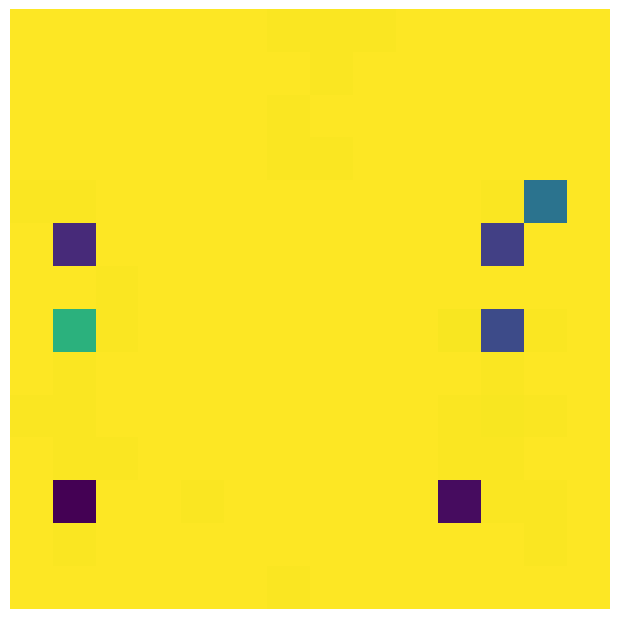

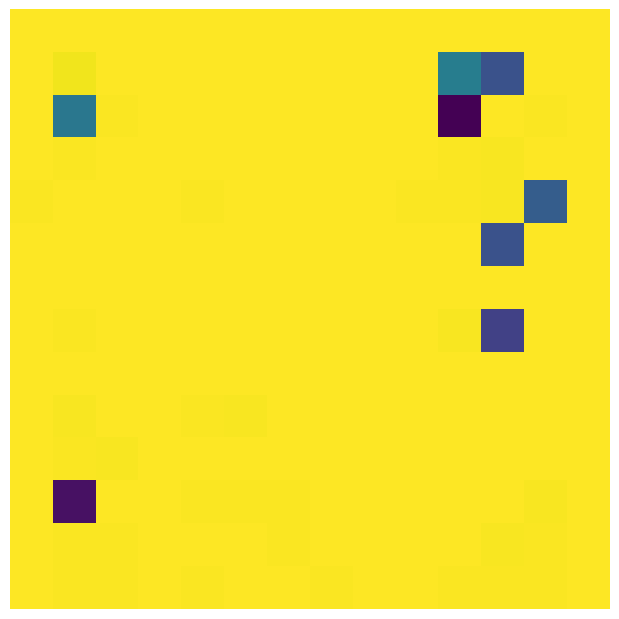

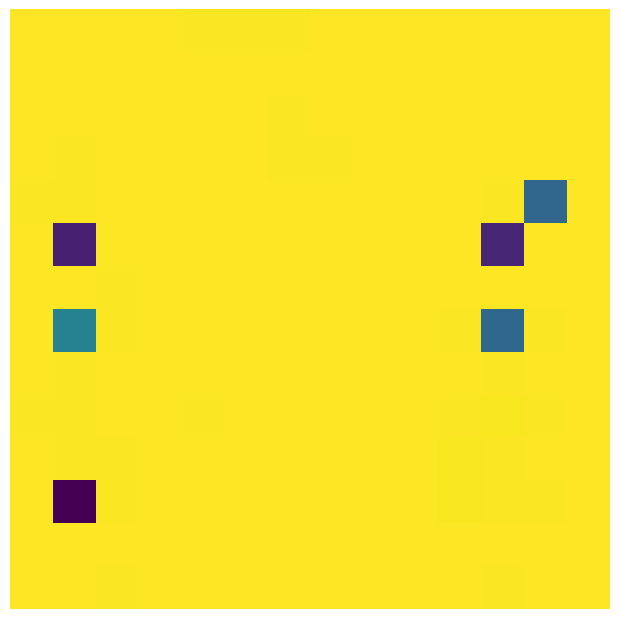

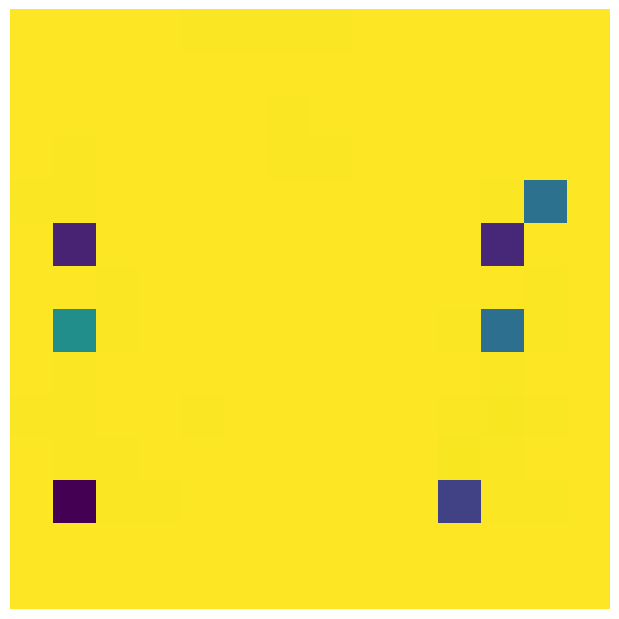

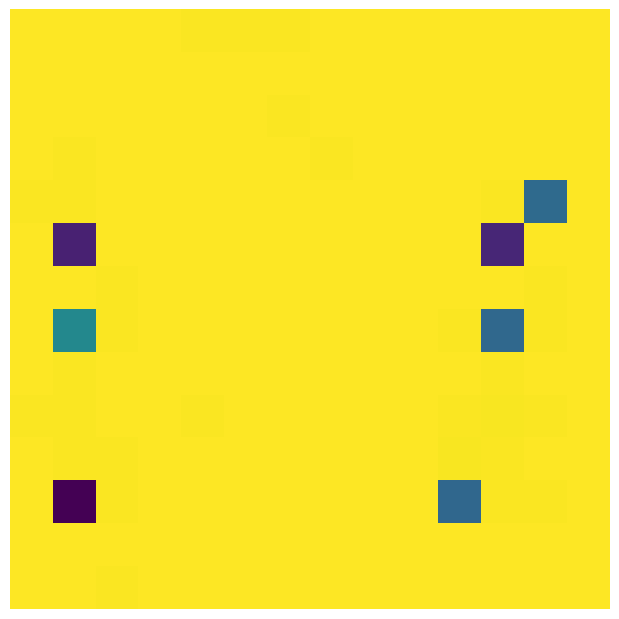

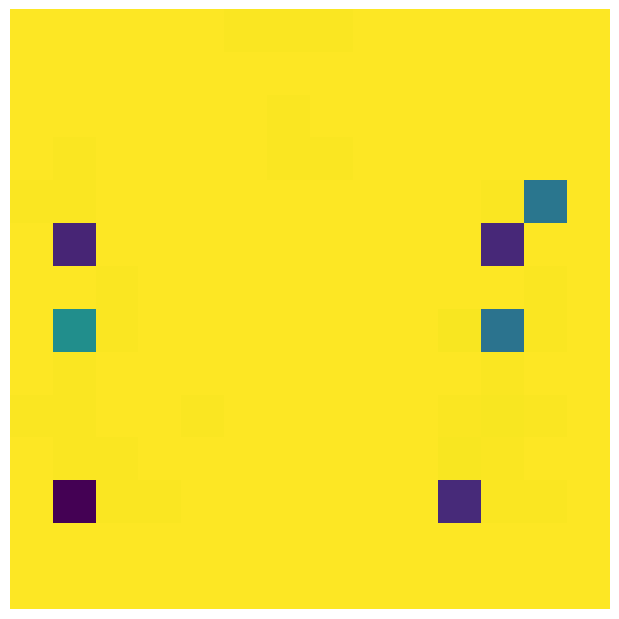

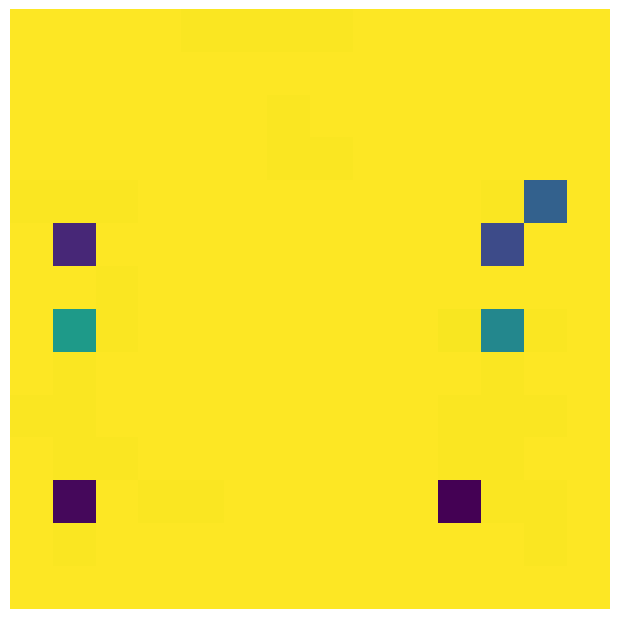

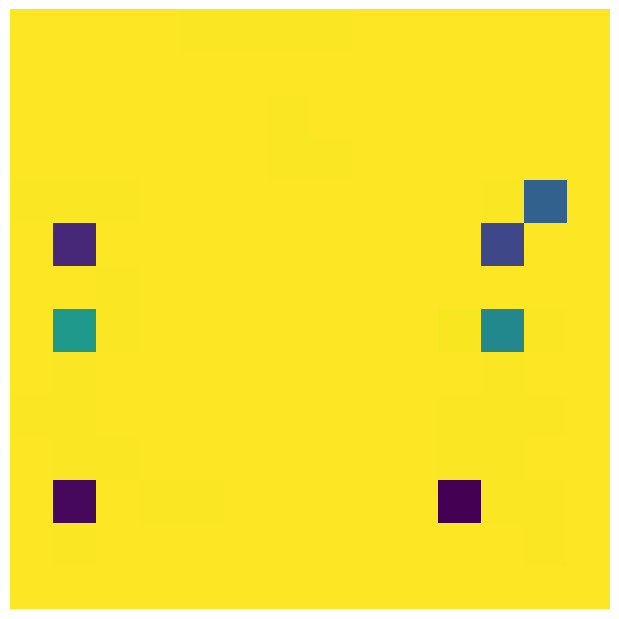

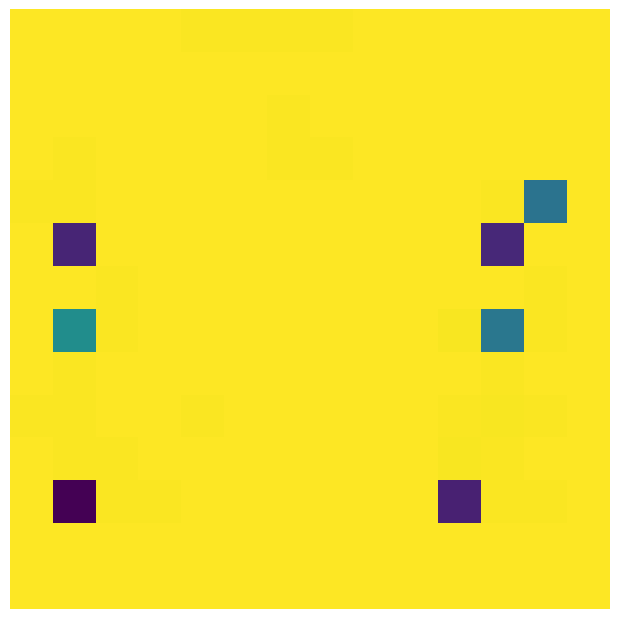

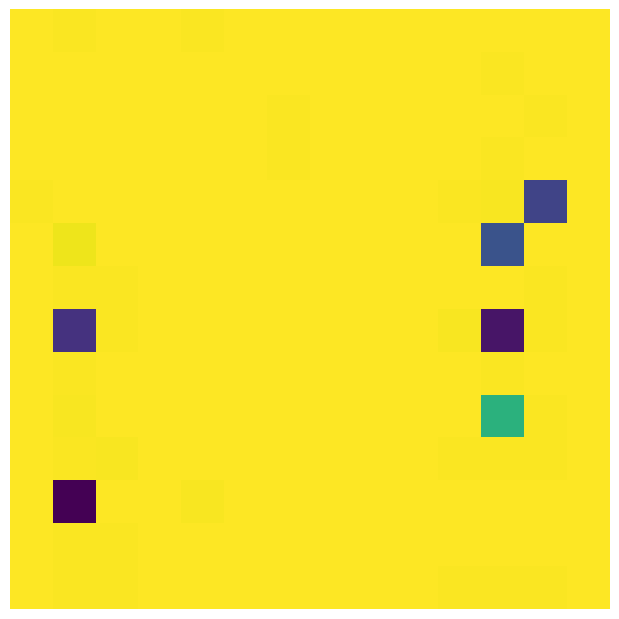

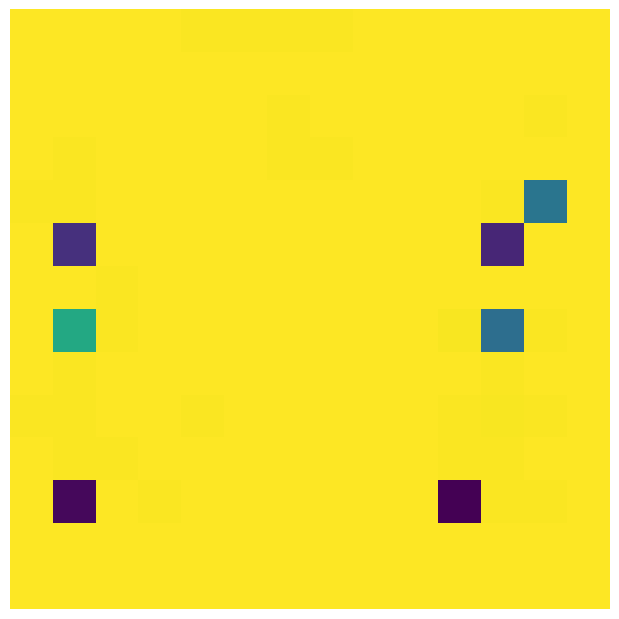

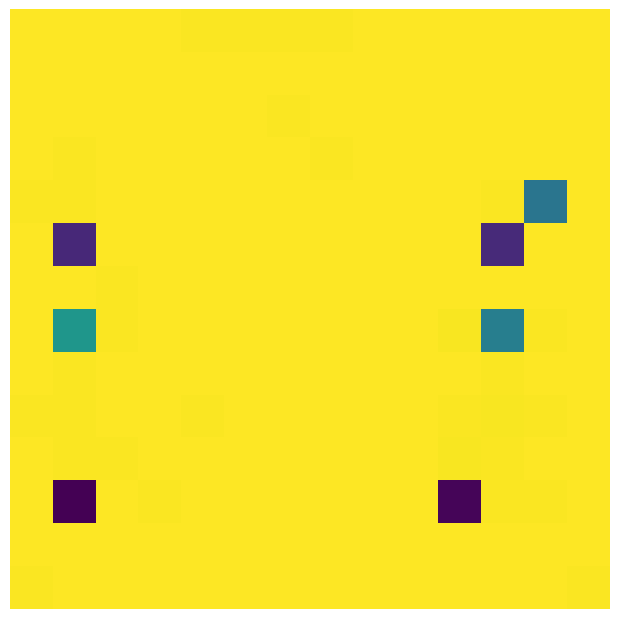

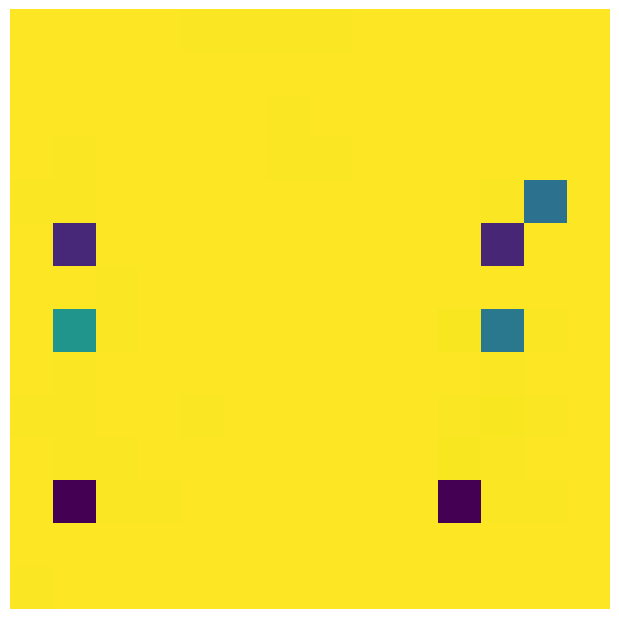

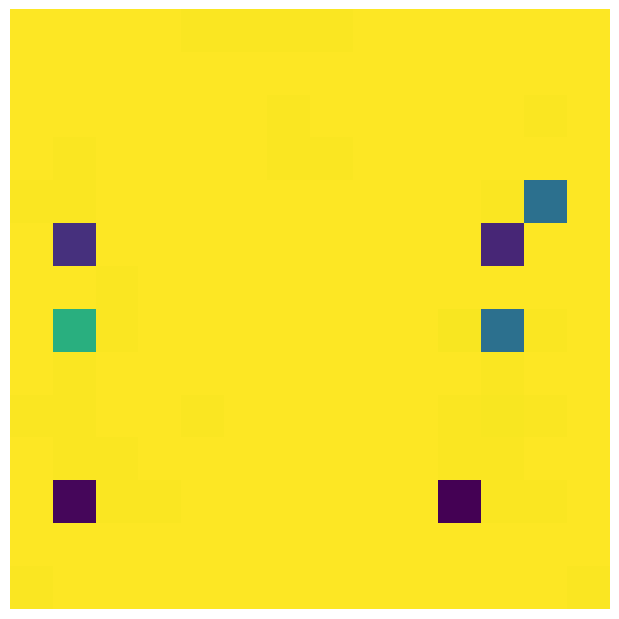

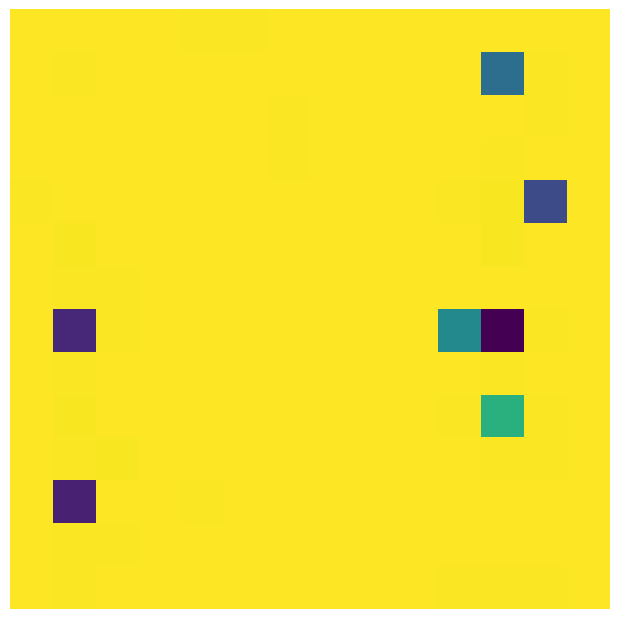

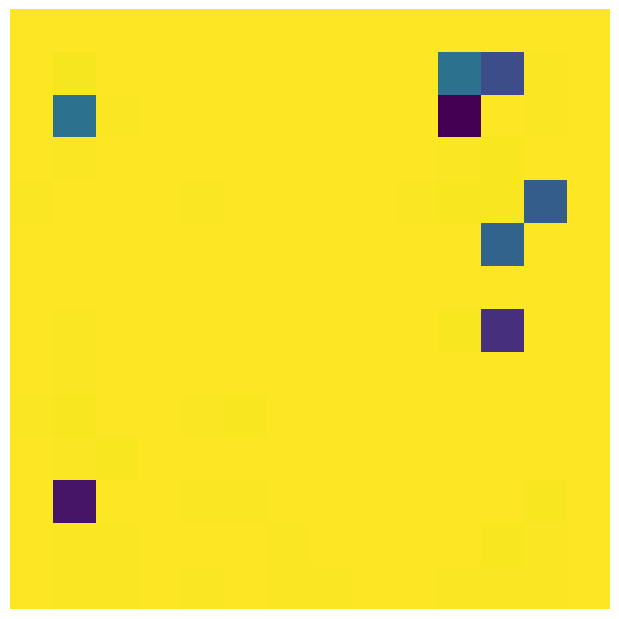

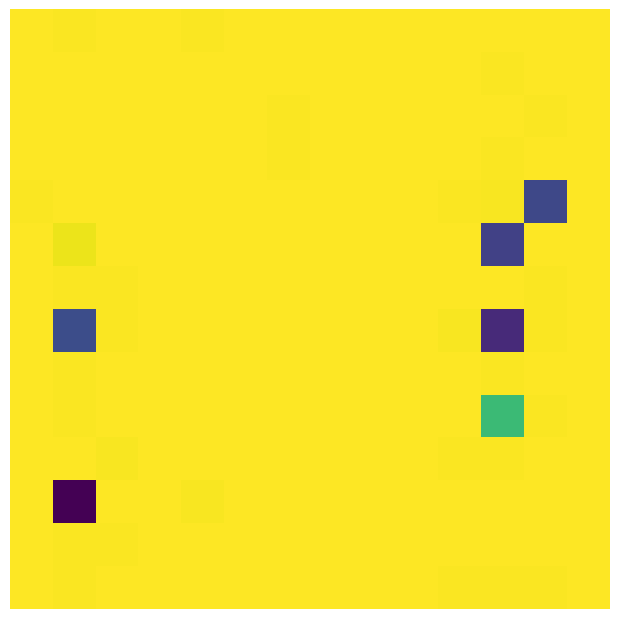

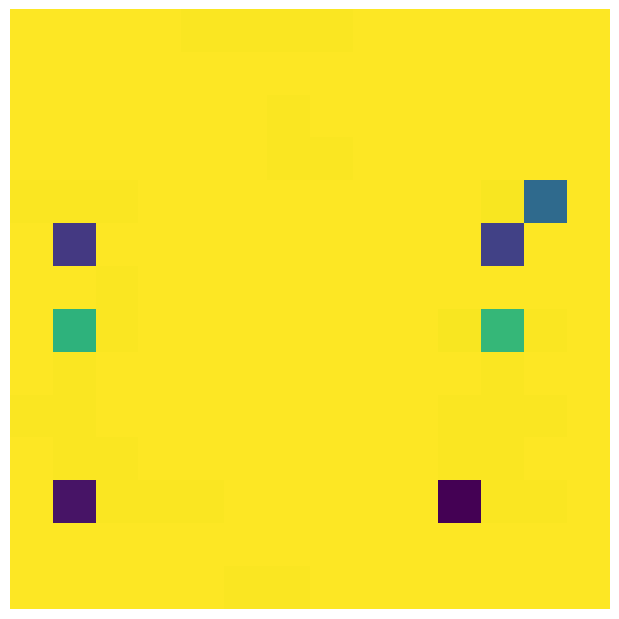

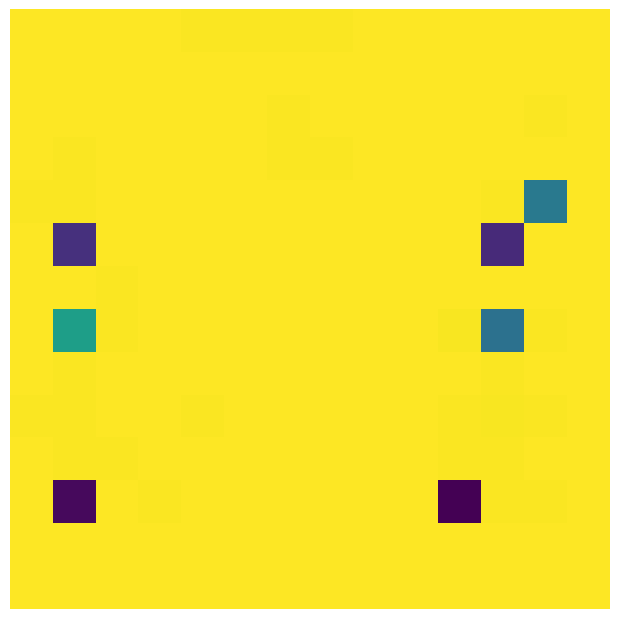

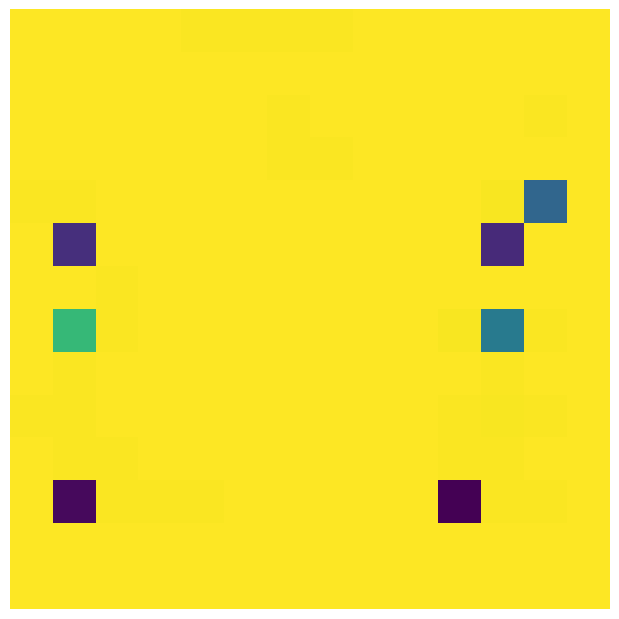

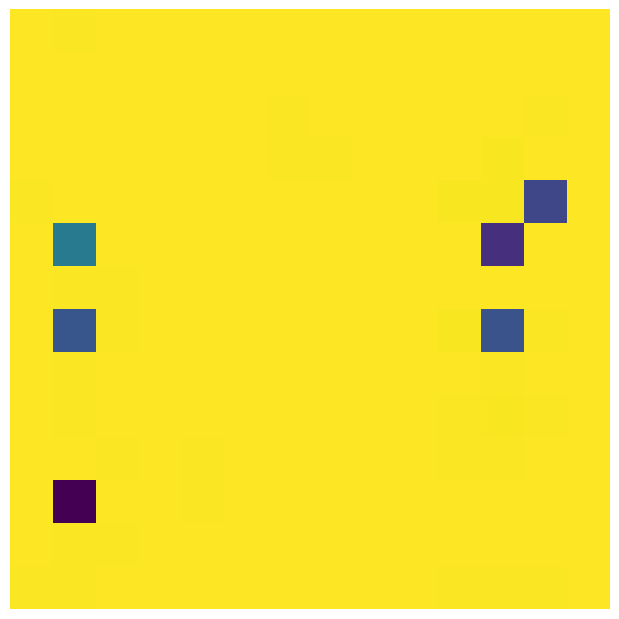

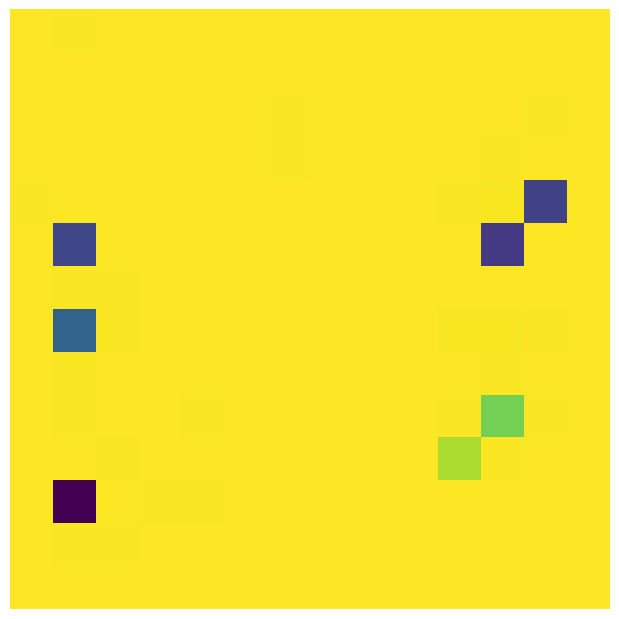

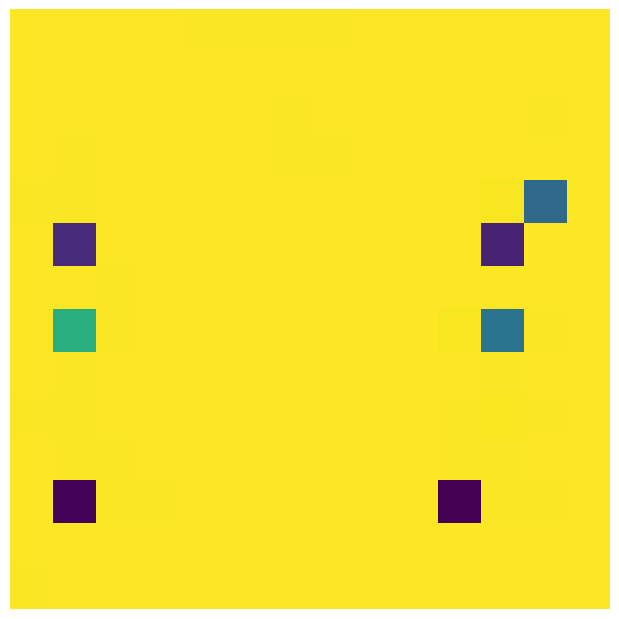

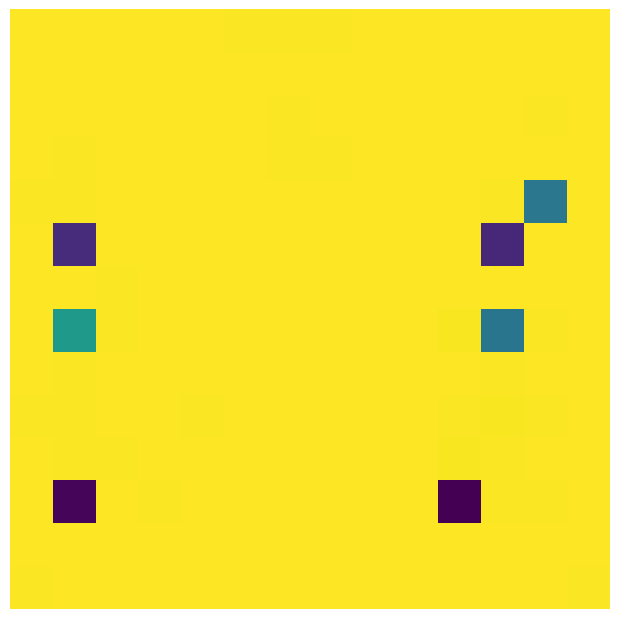

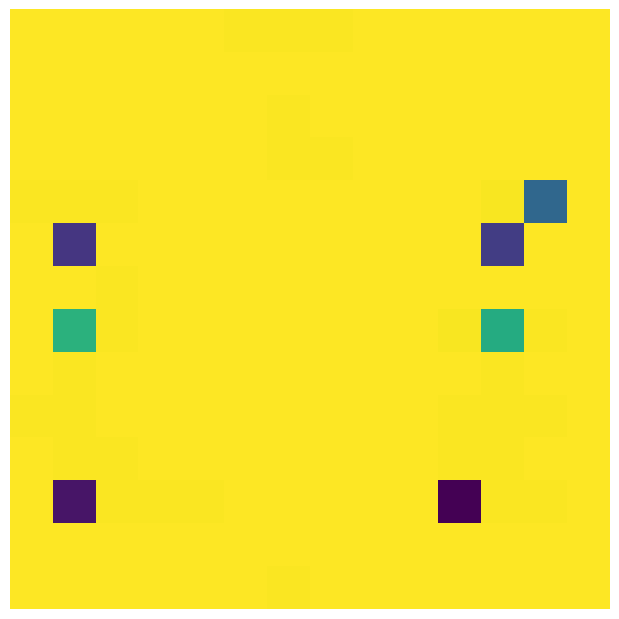

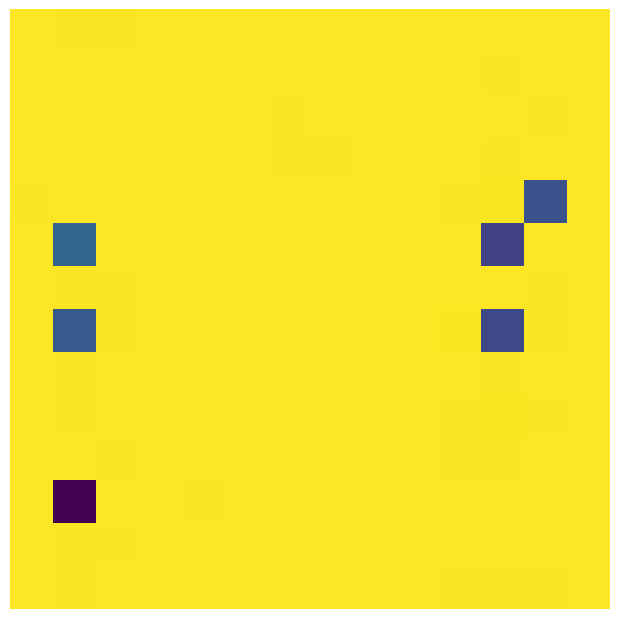

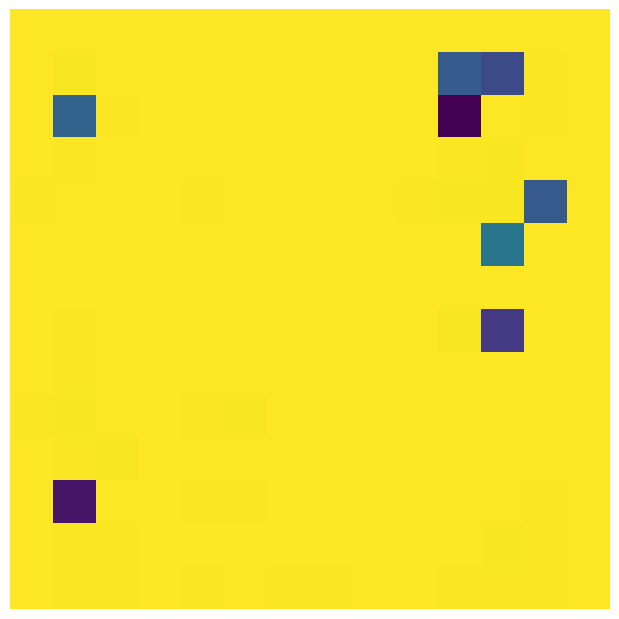

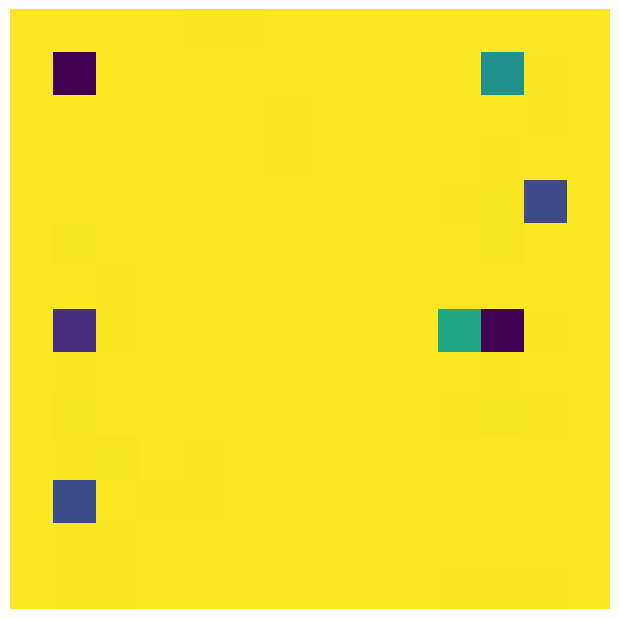

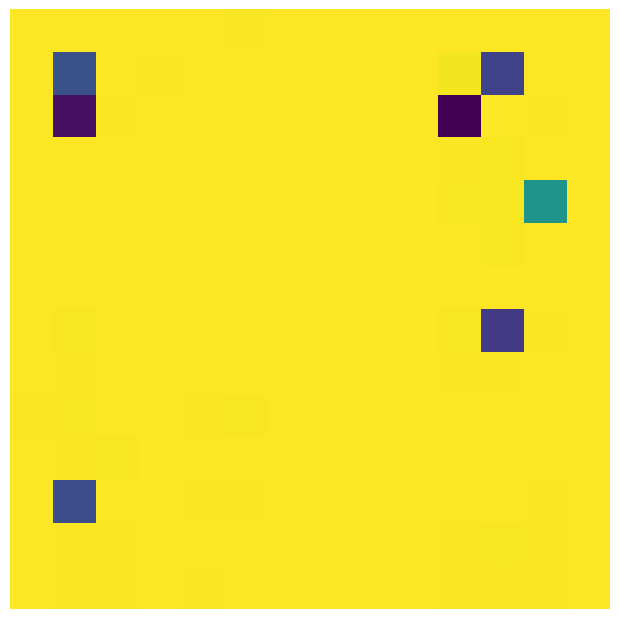

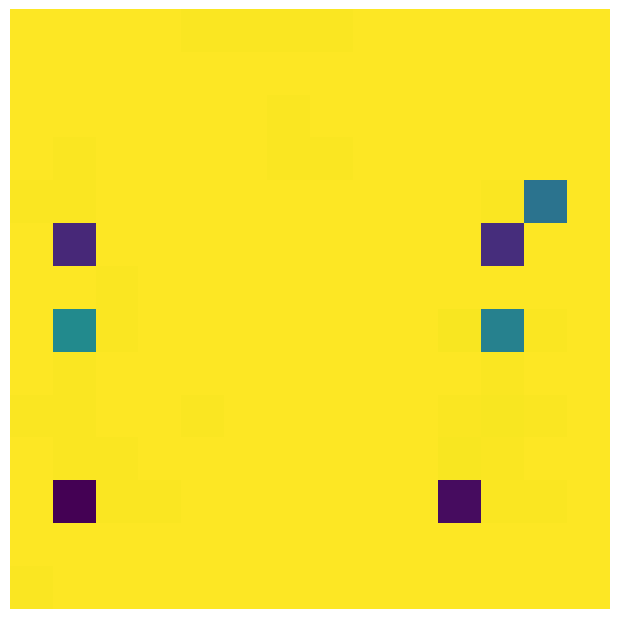

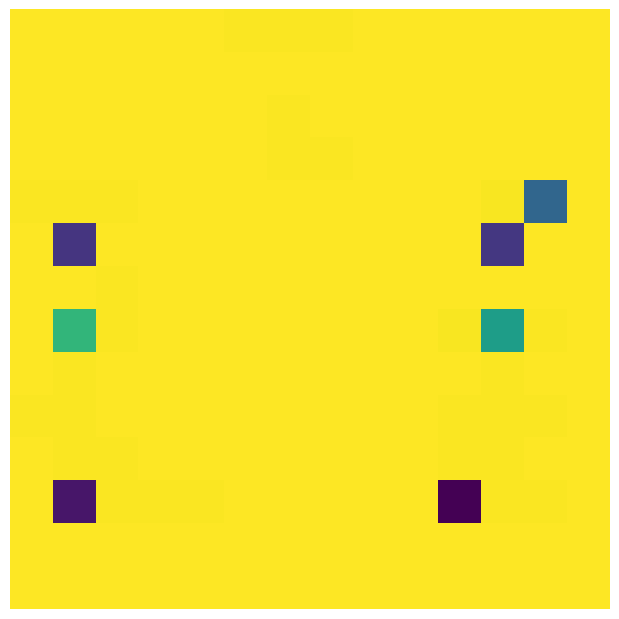

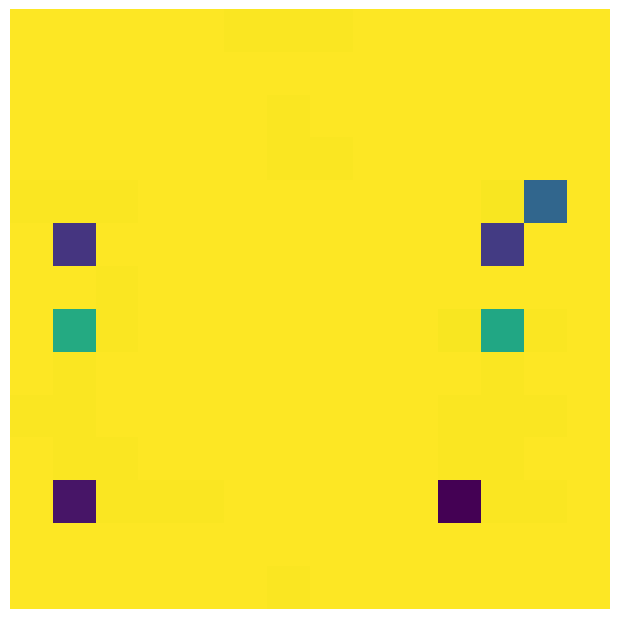

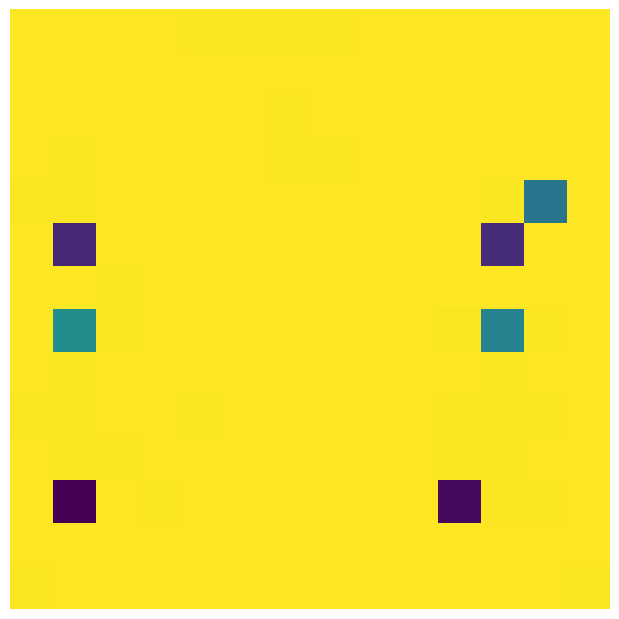

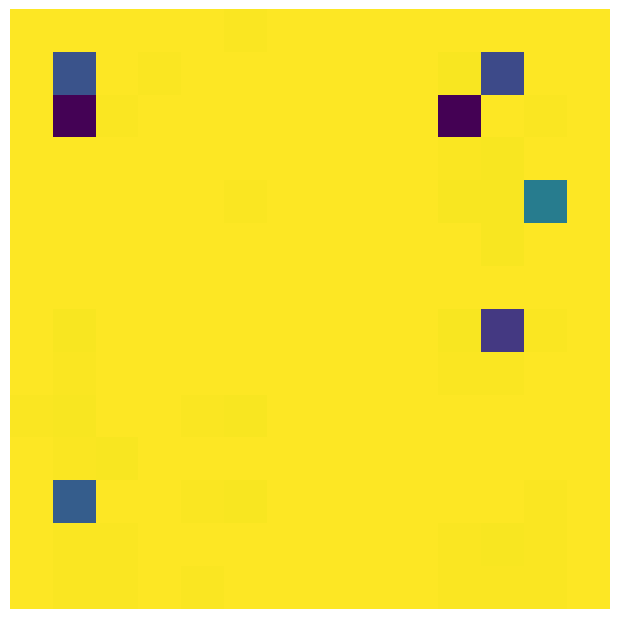

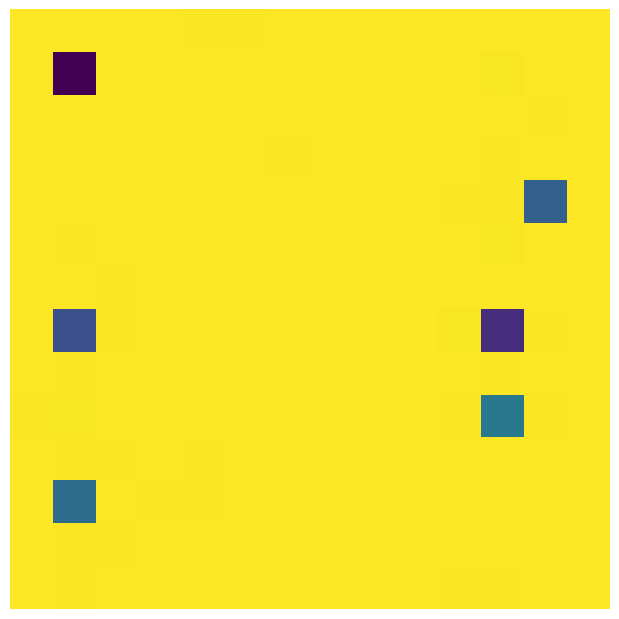

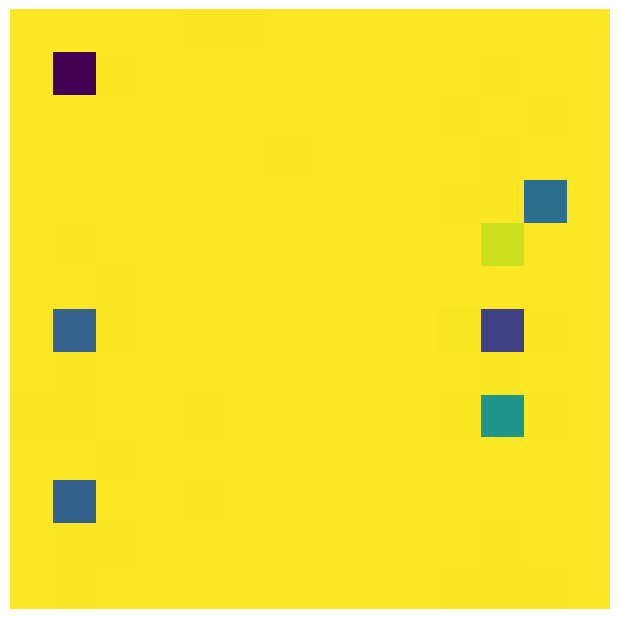

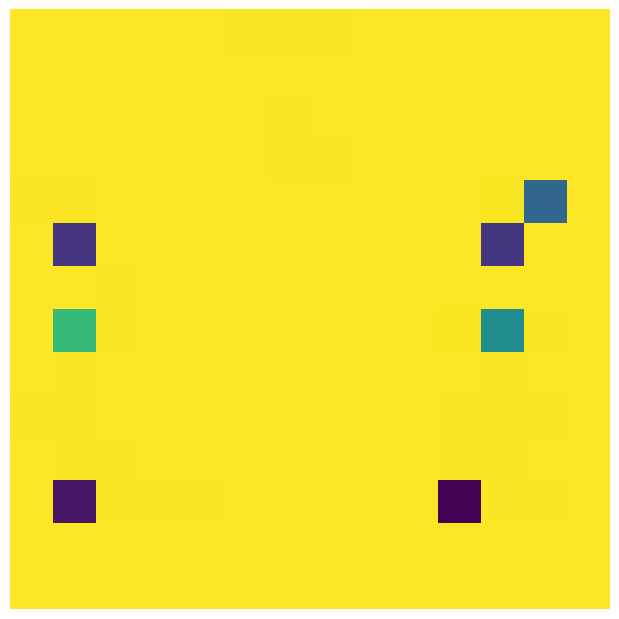

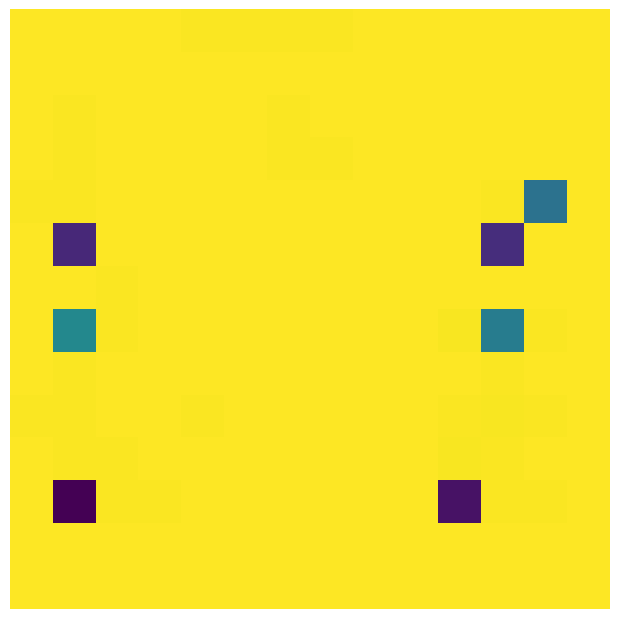

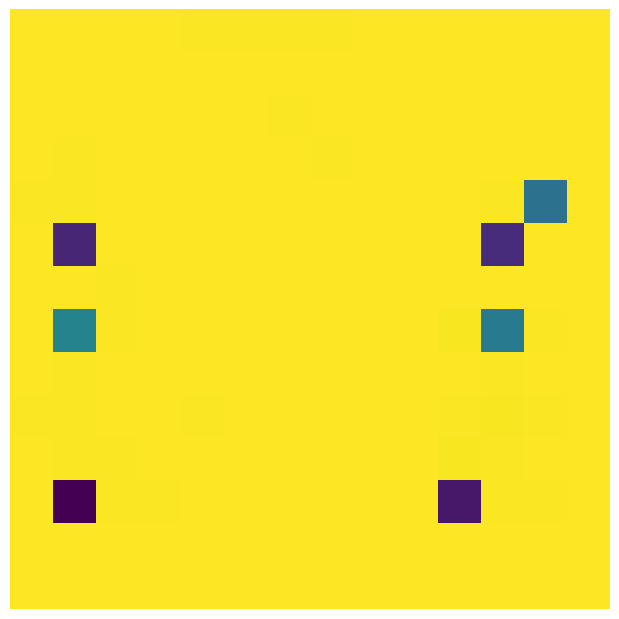

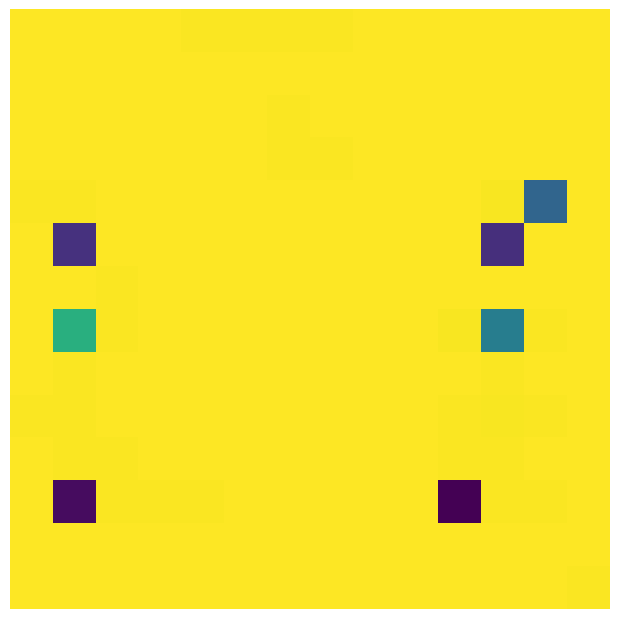

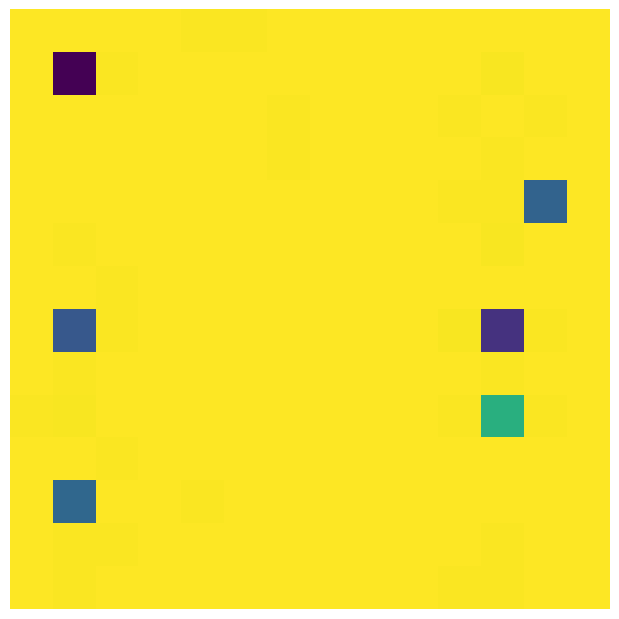

In [183]:
import numpy as np
from os import listdir
from os.path import isfile, join
from sklearn.decomposition import PCA

from transformers import ViTImageProcessor, ViTModel
from PIL import Image, ImageDraw
import requests

model_string = 'google/vit-large-patch16-224-in21k'
model_name = str.split(model_string, '/')[1]

images_variations = [f for f in listdir('images_variations') if isfile(join('images_variations', f))]

for image_filename_with_extension in images_variations:

    image_filename = str.split(image_filename_with_extension, '.')[0]
    image = Image.open('images_variations/' + image_filename_with_extension)

    processor = ViTImageProcessor.from_pretrained(model_string)
    model = ViTModel.from_pretrained(model_string)

    inputs = processor(images=image, return_tensors="pt")
    outputs = model(**inputs, output_hidden_states=True)

    # hidden_states is a tuple of (embeddings + all layer outputs)
    all_hidden_states = outputs.hidden_states

    # Example: Totally 25 layers: take middle layer 13
    # Totally 24 layers: take 12
    if len(all_hidden_states) % 2:
        middle_layer_number = int((len(all_hidden_states) + 1 )/ 2)
    else:
        middle_layer_number = int(len(all_hidden_states) / 2)
        # or maybe +1?
    middle_layer_output = all_hidden_states[middle_layer_number]

    # print(f"Number of layers: {len(all_hidden_states)}")
    # print(f"Shape of middle layer {middle_layer_number}: {middle_layer_output.shape}")

    # last_hidden_state = outputs.last_hidden_state
    X = middle_layer_output.detach().numpy()[0][1:,:] #Tensor with activations from the middle layer

    pca = PCA(n_components=1)
    X_reduced = pca.fit_transform(X)
    # print(pca.explained_variance_ratio_)
    # print(pca.singular_values_)
    # # 1. Select the first component (eigenvector)
    # first_component = pca.components_[0] # Shape: (n_features,)

    # # 2. Project data (n_samples, 1) using the component
    # X_reduced = pca.transform(X)[:, 0].reshape(-1, 1)

    # # 3. Reconstruct: X_orig = (Reduced_Data * Components) + Mean
    # # Note: Transpose first_component for matrix multiplication
    # reconstruction = np.dot(X_reduced, first_component.reshape(1, -1)) + pca.mean_
    doe_die_image = X_reduced.reshape(14,14)

    fig = plt.figure(frameon=False)
    fig.set_size_inches(6,6)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)

    ax.imshow(doe_die_image,cmap='viridis', aspect='auto', interpolation=None)


    # cb = plt.colorbar() 
    # cb.remove() 
    # plt.axis('off') # For the figure we don't need all the axis and legends
    fig.savefig('images_heatmap/' + image_filename + '_heatmap_' + model_name + '.jpg')
    # plt.close()
    # plt.show()

    # This part is for combining the heatmap with the input picture
    img = Image.open('images_variations/' + image_filename_with_extension).convert("RGBA")
    x,y = img.size
    img2 = Image.open('images_heatmap/' + image_filename + '_heatmap_' + model_name + '.jpg').convert("RGBA").resize((x,y))

    img.putalpha(225)
    img2.putalpha(45)

    img3 = Image.alpha_composite(img, img2)
    img3.save('images_result_combined/' + image_filename + '_' + model_name + '.png')


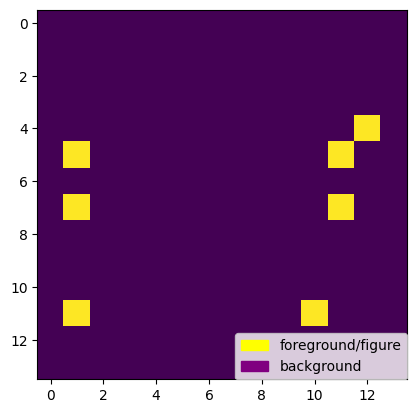

In [166]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

## color map and labels
t = 1 ## alpha value
cmap = {0:[1.0,1.0,0.0],1:[0.5,0.0,0.5]}
labels = {0:'foreground/figure',1:'background'}
arrayShow = np.where(
    doe_die_image < 0,
    1,
    0,)
## create patches as legend
patches =[mpatches.Patch(color=cmap[i],label=labels[i]) for i in cmap]

plt.imshow(arrayShow)
plt.legend(handles=patches, loc=4, borderaxespad=0.)
plt.show()
